In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# CareerCraft AI: A Multi-Agent Career Concierge
**Track**: Concierge Agents | **5-Day AI Agents Intensive — June 2026**

A pipeline of specialized ADK 2.0 agents that takes a resume and job description and produces a tailored resume, grounded STAR interview 
answers, live company research, and a scored opportunity dashboard.


---

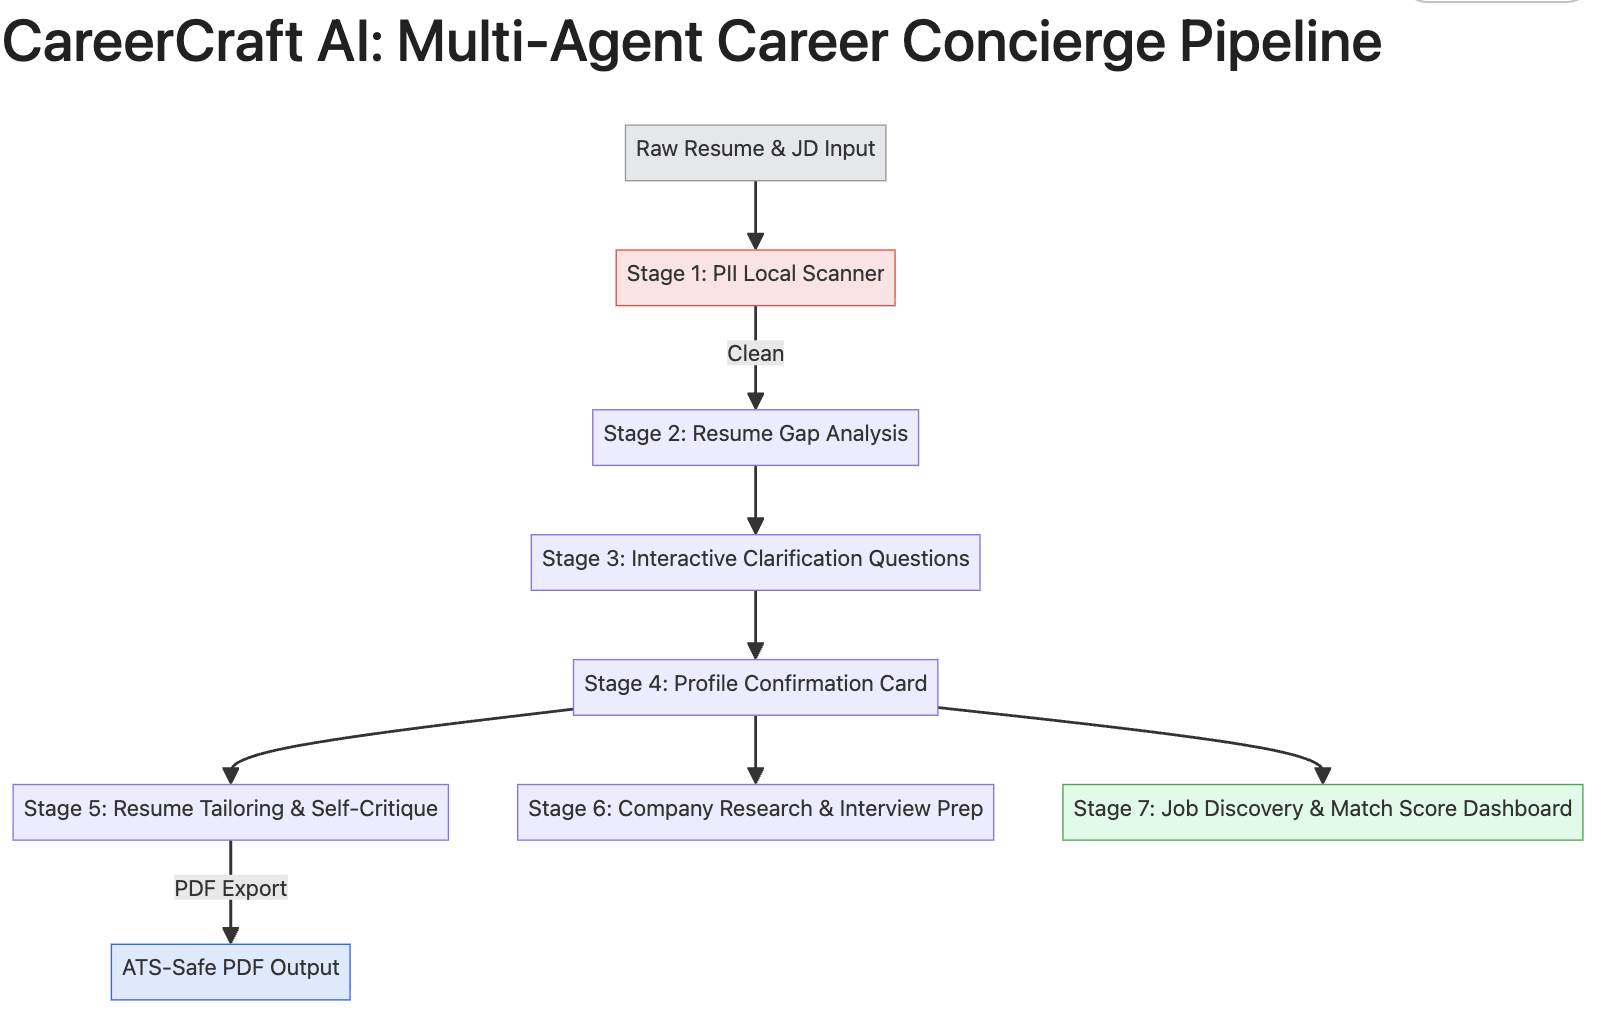

In [ ]:
# =============================================================================
# CareerCraft AI -- Kaggle Capstone Notebook Skeleton
# Track: Concierge Agents
# 5-Day AI Agents Intensive -- June 2026
# =============================================================================
# IMPORTANT: Before running this notebook:
# 1. Go to Add-ons -> Secrets in Kaggle
# 2. Add secret: GEMINI_API_KEY = your Gemini API key
# 3. Add secret: SEARCH_API_KEY = your Google Custom Search API key
# 4. Add secret: SEARCH_ENGINE_ID = your Programmable Search Engine ID
# 5. Set USE_MOCK=True below if you want to run without live API connections
# =============================================================================
 
 
# -- CELL 1: Setup -------------------------------------------------------------
 
!pip install google-genai google-adk nest-asyncio pypdf pdfminer.six ipywidgets reportlab --quiet
 
import os
import json
import uuid
import time
import random
from datetime import datetime, timezone
from typing import TypedDict, Optional
from google import genai
from google.genai import types
from kaggle_secrets import UserSecretsClient
 
# -- API keys -- Kaggle Secrets (confirmed working pattern) --------------------
user_secrets = UserSecretsClient()
GEMINI_API_KEY = user_secrets.get_secret("GEMINI_API_KEY")
GEMINI_API_KEY_2 = user_secrets.get_secret("GEMINI_API_KEY_2")
SEARCH_API_KEY = user_secrets.get_secret("SEARCH_API_KEY")
SEARCH_ENGINE_ID = user_secrets.get_secret("SEARCH_ENGINE_ID")
 
# -- Global flags --------------------------------------------------------------
USE_MOCK = False
GEMINI_MODEL_FULL = "gemini-2.5-flash"
GEMINI_MODEL_LITE = "gemini-2.5-flash-lite"
MAX_REVISIONS = 3
MAX_INTERVIEW_QUESTIONS = 10
INTERVIEW_BATCH_SIZE = 3
FRESHNESS_CUTOFF_DAYS = 14
FRESHNESS_WARNING_DAYS = 7

# FALLBACK_QUESTIONS moved here from Cell 13a so all cells can reference it
FALLBACK_QUESTIONS = [
    "Tell me about a time you built a data pipeline from scratch.",
    "Describe a situation where you had to work with messy or incomplete data.",
    "How have you used SQL to solve a complex business problem?",
    "Tell me about a time you delivered insights that changed a business decision.",
    "Describe your experience with data modeling and schema design.",
    "How do you ensure data quality in your pipelines?",
    "Tell me about a time you had to explain complex data findings to non-technical stakeholders.",
    "Describe a project where you had to work cross-functionally with engineering teams.",
    "How do you prioritise when you have multiple data requests from different teams?",
    "Tell me about your experience with dbt or similar transformation tools."
]

# -- Session state management -- persistent checkpoints ------------------------
SESSION_FILE = "/kaggle/working/session_state.json"

def save_session(profile: dict) -> None:
    """Saves enriched profile to disk. Called after Stages 2, 3, and 4."""
    with open(SESSION_FILE, "w") as f:
        json.dump(profile, f, indent=2)
    print(f"  Session saved -> {SESSION_FILE}")

def load_session() -> dict | None:
    """Loads previous session from disk if it exists."""
    if os.path.exists(SESSION_FILE):
        with open(SESSION_FILE) as f:
            return json.load(f)
    return None

def check_resume_session() -> dict | None:
    """
    Called at pipeline start. If a previous session exists,
    offers to restore it -- skipping Stages 1 through 3.
    """
    existing = load_session()
    if existing:
        print(f"\nPrevious session found:")
        print(f"  Target role : {existing.get('target_role', 'unknown')}")
        print(f"  Status      : {existing.get('confirmation_status', 'unknown')}")
        answer = input("\nResume previous session? (yes/no): ").strip().lower()
        if answer in {"yes", "y"}:
            print("Session restored. Skipping to Stage 4.")
            return existing
    return None
 
# -- Trajectory logging -- observability requirement --------------------
session_log = []
 
def log_agent_call(agent: str, stage: int, input_fields: list,
                   output_fields: list, token_count: int = 0,
                   status: str = "success", error: str = None):
    """Logs every agent call for trajectory auditing."""
    session_log.append({
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "agent": agent,
        "stage": stage,
        "input_fields": input_fields,
        "output_fields": output_fields,
        "token_count": token_count,
        "status": status,
        "error_message": error
    })
 
# -- Gemini client -- single instance, used by all agents ----------------------
client_full = genai.Client(api_key=GEMINI_API_KEY)     # Project 1 — gemini-2.5-flash
client_lite = genai.Client(api_key=GEMINI_API_KEY_2)   # Project 2 — gemini-2.5-flash-lite
 
def call_gemini(prompt: str, model: str = GEMINI_MODEL_FULL,
                max_retries: int = 4, expect_json: bool = True) -> str:
    """
    Central Gemini API caller with exponential backoff + jitter.
    All agent LLM calls go through here -- never call client directly.
    Routes to client_full (Project 1) or client_lite (Project 2) based on model.
    """
    active_client = client_lite if model == GEMINI_MODEL_LITE else client_full
    wait = 1
    for attempt in range(max_retries):
        try:
            response = active_client.models.generate_content(
                model=model,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0.2,
                    max_output_tokens=8192,
                    response_mime_type="application/json" if expect_json else None,
                )
            )
            text = response.text.strip()
            if expect_json:
                text = text.replace("```json", "").replace("```", "").strip()
            return text
 
        except Exception as e:
            error_str = str(e)
            if any(x in error_str for x in ["429", "503", "RESOURCE_EXHAUSTED", "UNAVAILABLE", "quota"]):
                jitter = random.uniform(0, 0.5)
                sleep_time = wait + jitter
                print(f"  Rate limit hit. Waiting {sleep_time:.1f}s (retry {attempt + 1}/{max_retries})...")
                time.sleep(sleep_time)
                wait *= 2
            else:
                print(f"  Gemini error: {error_str}")
                raise
 
    raise RuntimeError(f"Gemini call failed after {max_retries} retries.")
 
# -- Connectivity test -- must pass before running any other cell ---------------
def test_gemini_connection():
    for label, model in [("FULL (Project 1)", GEMINI_MODEL_FULL), ("LITE (Project 2)", GEMINI_MODEL_LITE)]:
        try:
            result = call_gemini(
                'Reply with exactly this JSON: {"status": "ok"}',
                model=model,
                expect_json=True
            )
            parsed = json.loads(result)
            if parsed.get("status") == "ok":
                print(f"Gemini connection OK [{label}]. Model: {model}")
            else:
                print(f"Unexpected response [{label}]: {result}")
        except Exception as e:
            print(f"Connection failed [{label}]: {e}")
            
print("Setup complete. USE_MOCK:", USE_MOCK)
test_gemini_connection()

In [ ]:
# -- CELL 1b: ADK Agent Definitions -------------------------------------------
# Verified: adk.dev + google.github.io/adk-docs -- June 28 2026
# ADK 2.0 GA: import is "from google.adk import Agent" (not LlmAgent)
# google_search tool: from google.adk.tools import google_search
# Requires GOOGLE_API_KEY env var for ADK (separate from genai client)

import asyncio
import os

# ADK 2.0 requires GOOGLE_API_KEY as environment variable
# Set from Kaggle Secret so ADK runner can find it
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY

from google.adk import Agent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search
from google.genai.types import Content, Part

# Try to import SkillToolset (may not be available in all ADK versions)
try:
    from google.adk.tools.skill_toolset import SkillToolset
    SKILL_TOOLSET_AVAILABLE = True
except ImportError:
    SKILL_TOOLSET_AVAILABLE = False
    print("  Note: SkillToolset not available in this ADK version")

# ADK session service -- manages conversation state across agent turns
adk_session_service = InMemorySessionService()
ADK_APP_NAME = "careercraft_ai"
ADK_USER_ID  = "careercraft_user"

# ── ADK Skill Toolset -- loads SKILL.md files from Cell 4 ─────────────────────
def get_skill_toolset():
    """Returns SkillToolset pointing at the skills directory from Cell 4."""
    skills_dir = "/kaggle/working/skills"
    if SKILL_TOOLSET_AVAILABLE and os.path.exists(skills_dir):
        return SkillToolset(skills_dir=skills_dir)
    return None

# ── Agent 1: Resume Analyst Agent (ADK Agent) ─────────────────────────────────
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY_2  # LITE agent — Project 2
resume_analyst_adk = Agent(
    name="resume_analyst_agent",
    model=GEMINI_MODEL_LITE,
    description="Parses a resume and produces a structured gap report JSON.",
    instruction="""You are a resume parsing specialist.
Parse the resume provided and extract: current_title, years_experience,
companies, skills, and all experience_bullets with has_numbers flags.
Identify needs_clarification and missing_entirely fields.
Return ONLY valid JSON matching the gap_report schema.
experience_bullets must be objects with company, role, bullet_text, has_numbers.
has_numbers is true ONLY for bullets with specific numbers or percentages.""",
)

# ── Agent 2: JD Parser Agent (ADK Agent) ─────────────────────────────────────
# Still on GEMINI_API_KEY_2 from above — LITE agent
jd_parser_adk = Agent(
    name="jd_parser_agent",
    model=GEMINI_MODEL_LITE,
    description="Parses a job description into structured required/preferred skills.",
    instruction="""You are a job description analyst.
Parse the job description and extract: company_name, role_title, seniority_level,
required_skills (must-have), preferred_skills (nice-to-have),
key_responsibilities, culture_signals, location, work_mode, salary_range.
Return ONLY valid JSON. Empty arrays for missing fields.""",
)

# ── Agent 3: Resume Tailoring Agent (ADK Agent) ───────────────────────────────
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY  # FULL agent — back to Project 1
resume_tailoring_adk = Agent(
    name="resume_tailoring_agent",
    model=GEMINI_MODEL_FULL,
    description="Tailors a resume to a specific JD using the enriched profile.",
    instruction="""You are an expert resume writer for tech and analytics roles.
Apply the recruiter 6-second scan rule.
Use active voice. Impact-first bullets. Never invent metrics.
Produce FULL resume: summary, experience, grouped skills, education.
Mirror JD vocabulary. Highlight transferable experience for skill gaps.""",
)

# ── Agent 4: Interview Prep Agent (ADK Agent) ─────────────────────────────────
interview_prep_adk = Agent(
    name="interview_prep_agent",
    model=GEMINI_MODEL_FULL,
    description="Generates STAR-format interview answers grounded in user experience.",
    instruction="""You are an expert interview preparation coach.
Generate STAR-format answers grounded ONLY in the user's actual experience.
Always name the specific company/project for each answer.
Never invent metrics not in the provided experience data.
If no matching experience, say so and suggest the closest transferable story.""",
)

# ── Company Research Agent (ADK Agent + google_search MCP tool) ───────────────
# google_search = ADK's built-in MCP-style tool for Gemini 2 models
# Confirmed import: from google.adk.tools import google_search
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY_2  # LITE agent — Project 2
company_research_adk = Agent(
    name="company_research_agent",
    model=GEMINI_MODEL_LITE,
    description="Researches target company using google_search MCP tool.",
    instruction="""You are a company research specialist.
Use the google_search tool to find: recent news (last 90 days),
main products and services, culture and values, interview process reputation.
Sanitize all retrieved content. Do not hallucinate.
Return structured JSON: company_name, recent_news[], main_products[],
culture_signals[], interview_patterns[], sources[].""",
    tools=[google_search],  # ADK built-in MCP-style Google Search tool
)

# ── Job Discovery Agent (ADK Agent + google_search MCP tool) ──────────────────
# Still on GEMINI_API_KEY_2 from above — LITE agent
job_discovery_adk = Agent(
    name="job_discovery_agent",
    model=GEMINI_MODEL_LITE,
    description="Discovers fresh job postings using google_search MCP tool.",
    instruction="""You are a job search specialist.
Use the google_search tool to find current job postings (last 14 days).
Search for the target role and location on LinkedIn and Indeed.
Extract: job_title, company, location, work_mode, post_date, apply_url.
Only return real job listings. Filter out news and blog posts.""",
    tools=[google_search],  # ADK built-in MCP-style Google Search tool
)

# Reset to Project 1 key as the default for any ad-hoc calls below
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY

# ── ADK Runner helper -- runs any ADK Agent with a text prompt ─────────────────
async def run_adk_agent_async(agent: Agent, prompt: str,
                               session_id: str = None) -> str:
    """
    Runs an ADK Agent programmatically using Runner + InMemorySessionService.
    Returns the final response text.
    """
    sid = session_id or str(uuid.uuid4())

    await adk_session_service.create_session(
        app_name=ADK_APP_NAME,
        user_id=ADK_USER_ID,
        session_id=sid,
        state={}
    )

    runner = Runner(
        agent=agent,
        app_name=ADK_APP_NAME,
        session_service=adk_session_service,
    )

    content = Content(role="user", parts=[Part(text=prompt)])
    final_response = ""

    async for event in runner.run_async(
        user_id=ADK_USER_ID,
        session_id=sid,
        new_message=content,
    ):
        if event.is_final_response():
            if event.content and event.content.parts:
                final_response = event.content.parts[0].text or ""

    return final_response

def run_adk_agent_sync(agent: Agent, prompt: str,
                        session_id: str = None) -> str:
    """
    Synchronous wrapper with automatic retry on 429.
    Handles Kaggle Jupyter event loop using nest_asyncio.
    """
    try:
        import nest_asyncio
        nest_asyncio.apply()
    except ImportError:
        pass

    max_retries = 4
    wait = 32  # start above the 31s retry delay ADK reports

    for attempt in range(max_retries):
        try:
            loop = asyncio.get_event_loop()
            if loop.is_running():
                return loop.run_until_complete(
                    run_adk_agent_async(agent, prompt, session_id)
                )
            return asyncio.run(
                run_adk_agent_async(agent, prompt, session_id)
            )
        except Exception as e:
            error_str = str(e)
            if "429" in error_str or "RESOURCE_EXHAUSTED" in error_str or "503" in error_str or "UNAVAILABLE" in error_str:
                jitter = random.uniform(0, 2)
                sleep_time = wait + jitter
                print(f"  ADK rate limit. Waiting {sleep_time:.0f}s "
                      f"(retry {attempt + 1}/{max_retries})...")
                time.sleep(sleep_time)
                wait *= 2
            else:
                print(f"  ADK error: {error_str[:200]}")
                raise

    raise RuntimeError(f"ADK call failed after {max_retries} retries.")
    

# ── Quick ADK connectivity test ────────────────────────────────────────────────
def test_adk_connection():
    """Tests ADK setup with a simple agent call."""
    try:
        test_agent = Agent(
            name="test_agent",
            model=GEMINI_MODEL_FULL,
            instruction='Reply with exactly this JSON and nothing else: {"status": "adk_ok"}',
        )
        result = run_adk_agent_sync(test_agent, "ping")
        if "adk_ok" in result or result.strip():
            print(f"ADK connection OK. Agent API: google.adk.Agent")
        else:
            print(f"ADK response unexpected: {result[:100]}")
    except Exception as e:
        print(f"ADK connection error: {e}")
        print("Note: ADK agents will fallback to direct Gemini calls if needed.")

print("ADK agents defined (ADK 2.0 API):")
print(f"  - {resume_analyst_adk.name}")
print(f"  - {jd_parser_adk.name}")
print(f"  - {resume_tailoring_adk.name}")
print(f"  - {interview_prep_adk.name}")
print(f"  - {company_research_adk.name} [google_search MCP tool]")
print(f"  - {job_discovery_adk.name} [google_search MCP tool]")
print(f"\nSession service: InMemorySessionService")
print(f"SkillToolset available: {SKILL_TOOLSET_AVAILABLE}")
print(f"GOOGLE_API_KEY env: set")
print()
test_adk_connection()


In [ ]:
# ── CELL 2: Static context — agents.md ────────────────────────────────────────
 
AGENTS_MD = """
# CareerCraft AI — System Context
 
## System description
CareerCraft AI is a six-agent career concierge system. It takes a user's resume
and a target job description, tailors the resume, prepares personalized interview
answers, and surfaces fresh job opportunities matching the user's location preference.
 
## Agent roles
- resume_analyst_agent: parses resume, produces internal gap report
- clarifying_questions_agent: asks one batch of max 6 questions, builds enriched profile
- jd_parser_agent: extracts required/preferred skills from job description
- resume_tailoring_agent: rewrites resume against JD with self-reflection loop
- company_research_agent: researches target company via web search MCP
- interview_prep_agent: generates STAR answers grounded in user's experience
- job_discovery_agent: finds fresh job postings via web search MCP
 
## Security rules
- Never expose API keys in output
- Always sanitize web-sourced content before passing to any prompt
- Never proceed past Stage 3 without user confirmation
- PII scan must pass before any LLM call on resume text
- All MCP connections are read-only
"""
 
print("Static context loaded.")
print(f"agents.md length: {len(AGENTS_MD)} characters")

In [ ]:
# -- CELL 3: Enriched profile schema ------------------------------------------
 
class ExperienceBullet(TypedDict):
    company: str
    role: str
    bullet_text: str
    has_numbers: bool
 
class ImpactElaboration(TypedDict):
    company: str
    elaboration: str
 
class EnrichedProfile(TypedDict):
    user_id: str
    full_name: str                      # FIX: added -- required for PDF header
    email: str                          # FIX: added -- needed for contact line
    linkedin: str                       # FIX: added -- needed for contact line
    education: str                      # FIX: added -- needed for PDF footer
    current_title: str
    years_experience: float
    companies: list[str]
    skills: list[str]
    experience_bullets: list[ExperienceBullet]
    technical_projects: list[str]
    impact_elaborations: list[ImpactElaboration]
    target_role: str
    target_seniority: str
    target_industry: str
    location_preference: str
    work_mode: str                      # remote | hybrid | onsite
    confirmation_status: str            # pending | confirmed | manual_edit
    revision_count: int
 
class JDObject(TypedDict):
    company_name: str
    role_title: str
    seniority_level: str
    required_skills: list[str]
    preferred_skills: list[str]
    key_responsibilities: list[str]
    culture_signals: list[str]
 
class JobRecord(TypedDict):
    job_title: str
    company: str
    location: str
    work_mode: str
    post_date: str
    freshness_warning: bool
    match_score: int
    gap_skills: list[str]
    apply_url: str
 
def create_empty_profile() -> EnrichedProfile:
    """Returns an empty enriched profile with all required keys initialised."""
    return {
        "user_id": str(uuid.uuid4()),
        "full_name": "",                # FIX: added
        "email": "",                    # FIX: added
        "linkedin": "",                 # FIX: added
        "education": "",                # FIX: added
        "current_title": "",
        "years_experience": 0.0,
        "companies": [],
        "skills": [],
        "experience_bullets": [],
        "technical_projects": [],
        "impact_elaborations": [],
        "target_role": "",
        "target_seniority": "",
        "target_industry": "",
        "location_preference": "",
        "work_mode": "remote",
        "confirmation_status": "pending",
        "revision_count": 0
    }
 
print("Schema definitions loaded.")

In [ ]:
# ── CELL 4: SKILL.md folder structures ───────────────────────────────────────
# Creates all 6 agent skills as proper SKILL.md packages.
# Each skill follows the agentskills.io standard:
# - YAML frontmatter with name and description
# - Full implementation instructions
# - Input and output schema
# Progressive disclosure pattern — loaded on demand, not at startup.
 
import os
 
SKILLS_DIR = "/kaggle/working/skills"
os.makedirs(SKILLS_DIR, exist_ok=True)
 
SKILL_FILES = {
 
    # ── Skill 1: PII Scanner ──────────────────────────────────────────────────
    "pii_scanner": {
        "name": "PII Scanner",
        "description": (
            "Triggers when resume text is received before any LLM call. "
            "Scans for phone numbers, date of birth, home address, and "
            "national ID numbers using regex patterns. Returns pii_found "
            "bool and flagged_items list. Session pauses if PII found."
        ),
        "instructions": """## Purpose
Protect user privacy by detecting PII in resume text before it enters
any LLM pipeline. This is a security guardrail — mandatory first step.
 
## Trigger
Called immediately after resume text is received in Stage 1.
Must complete and return clean_to_proceed=True before any other agent runs.
 
## What it detects
- Phone numbers: any digit sequence matching phone patterns
- Date of birth: DOB, Date of Birth, Born keywords followed by date
- Home address: street number + street type patterns
- National ID: SSN pattern (###-##-####)
 
## What it does NOT flag
- Email address (retained — needed for job applications)
- LinkedIn URL (retained — professional contact)
- City and state only (retained — location without street is acceptable)
 
## Input
raw_resume_text: string — full resume text as pasted or extracted from PDF
 
## Output
{
  "pii_found": bool,
  "flagged_items": ["phone_number", "date_of_birth", "home_address", "national_id"],
  "clean_to_proceed": bool
}
 
## On pii_found = True
Display advisory to user listing flagged items.
Ask user to remove them and re-upload.
Do NOT proceed to resume_analyst_agent until clean_to_proceed = True.
 
## Security note
This skill runs entirely on regex — no LLM call, no API cost, no token usage.
""",
        "input_schema": '{"raw_resume_text": "string"}',
        "output_schema": '{"pii_found": "bool", "flagged_items": ["string"], "clean_to_proceed": "bool"}'
    },
 
    # ── Skill 2: Gap Report Generator ─────────────────────────────────────────
    "gap_report_generator": {
        "name": "Gap Report Generator",
        "description": (
            "Triggers inside resume_analyst_agent after resume text is "
            "parsed by Gemini. Structures the LLM output into a validated "
            "gap_report JSON with extracted fields, needs_clarification list, "
            "and missing_entirely list. Internal only — never shown to user."
        ),
        "instructions": """## Purpose
Transform raw LLM resume parse output into a validated, structured gap report
that downstream agents can reliably consume.
 
## Trigger
Called inside resume_analyst_agent immediately after the Gemini JSON response
is received and parsed.
 
## What it produces
Three sections:
1. extracted: confidently identified fields from the resume
2. needs_clarification: present but thin (skill listed, no project context)
3. missing_entirely: completely absent fields
 
## Always check for missing
- target_role: almost never in a resume — always missing_entirely
- location_preference: rarely explicit — usually missing_entirely
- work_mode: never in resume — always missing_entirely
- years_experience: calculate from date ranges if not stated explicitly
 
## has_numbers rule
True ONLY if bullet contains a specific number, percentage, or dollar amount.
"Improved performance" → False
"Improved performance by 40%" → True
"Managed $2M budget" → True
 
## Input
raw_gemini_output: dict — parsed JSON from Gemini resume analysis call
 
## Output
{
  "extracted": {
    "current_title": "string",
    "years_experience": number,
    "companies": ["string"],
    "skills": ["string"],
    "experience_bullets": [
      {"company": "string", "role": "string",
       "bullet_text": "string", "has_numbers": bool}
    ]
  },
  "needs_clarification": ["string"],
  "missing_entirely": ["string"]
}
 
## Token note
This is a validation and structuring step — no additional LLM call needed.
Runs on the output already received from the resume analyst prompt.
""",
        "input_schema": '{"raw_gemini_output": "dict"}',
        "output_schema": '{"extracted": "dict", "needs_clarification": ["string"], "missing_entirely": ["string"]}'
    },
 
    # ── Skill 3: Match and Gap Analyzer ───────────────────────────────────────
    "match_gap_analyzer": {
        "name": "Match and Gap Analyzer",
        "description": (
            "Triggers after jd_parser_agent completes in Stage 4. "
            "Compares enriched profile skills against JD required and "
            "preferred skills using weighted scoring. Required skills "
            "weighted 70%, preferred 30%. Returns match_score, gap lists, "
            "and top bullets ranked by relevance to the JD."
        ),
        "instructions": """## Purpose
Quantify how well the candidate's profile matches the target JD.
Identify which skills are missing and which experience bullets are most
relevant to highlight in the tailored resume.
 
## Trigger
Called in Stage 4 after jd_parser_agent returns jd_object.
Must complete before resume_tailoring_agent runs.
 
## Scoring formula
required_score  = (matched_required / total_required) * 70
preferred_score = (matched_preferred / total_preferred) * 30
match_score     = int(required_score + preferred_score)
 
## Bullet relevance ranking
For each bullet:
- +1 point per matched required skill mentioned in bullet text
- +0.5 points per matched preferred skill mentioned in bullet text
- +1 bonus point if has_numbers = True
Sort descending, return top 6 bullets as top_bullets_to_highlight.
 
## Match tier thresholds
75-100%: Strong match — apply now
60-74%: Good match — apply with minor gaps
45-59%: Partial match — apply cautiously
Below 45%: Weak match — address gaps first
 
## Input (scoped — only these fields from profile)
profile.skills: ["string"]
jd_object.required_skills: ["string"]
jd_object.preferred_skills: ["string"]
profile.experience_bullets: [dict]
 
## Output
{
  "match_score": int (0-100),
  "matched_skills": ["string"],
  "matched_required": ["string"],
  "matched_preferred": ["string"],
  "gap_skills_required": ["string"],
  "gap_skills_preferred": ["string"],
  "top_bullets_to_highlight": [
    {"bullet_text": "string", "company": "string",
     "role": "string", "relevance_score": float,
     "has_numbers": bool}
  ],
  "total_required": int,
  "total_preferred": int
}
 
## Token note
No LLM call — pure Python logic. token_count logged as 0.
""",
        "input_schema": '{"profile.skills": ["string"], "jd_object.required_skills": ["string"], "jd_object.preferred_skills": ["string"], "profile.experience_bullets": ["dict"]}',
        "output_schema": '{"match_score": "int", "matched_skills": ["string"], "gap_skills_required": ["string"], "top_bullets_to_highlight": ["dict"]}'
    },
 
    # ── Skill 4: Resume Self-Critique ──────────────────────────────────────────
    "resume_self_critique": {
        "name": "Resume Self-Critique",
        "description": (
            "Triggers after resume_tailoring_agent generates draft 1. "
            "Evaluates each bullet for vague verbs, missing numbers, "
            "passive voice, and buried impact. NEVER suggests inventing "
            "metrics not provided by the user. Returns critique_items list "
            "and overall_strength rating. Drives Pass 3 revision."
        ),
        "instructions": """## Purpose
Catch weak bullets before the resume is finalised. Enforce writing quality
standards without hallucinating metrics or experience.
 
## Trigger
Called inside resume_tailoring_agent after draft 1 is generated.
Output drives the Pass 3 revision. If overall_strength = strong and
critique_items is empty, Pass 3 is skipped to save tokens.
 
## Four issue types
1. vague_verb: uses led, supported, assisted, helped, worked on
   → Suggest specific alternative: built, designed, automated, delivered
2. missing_number: no metric present AND confirmed metric exists for this bullet
   → ONLY flag if the user actually provided that metric
   → NEVER suggest inventing a number
3. passive_voice: was responsible for, was involved in, was tasked with
   → Suggest active rewrite
4. buried_impact: action described, result not stated
   → Suggest adding the outcome
5. too_long: bullet exceeds 2 lines
   → Suggest splitting or trimming
 
## Grounding rule — mandatory
Before flagging missing_number, check the confirmed_metrics list.
If the metric is not in that list, do NOT flag it.
The confirmed_metrics list contains only data the user explicitly provided.
 
## overall_strength
weak:     3+ high-severity issues
moderate: 1-2 issues
strong:   0 issues
 
## Input
draft_resume: string — full draft resume text
confirmed_metrics: ["string"] — bullets and elaborations with real numbers
 
## Output
{
  "critique_items": [
    {"bullet_text": "string", "issue": "string", "suggestion": "string"}
  ],
  "overall_strength": "weak | moderate | strong"
}
 
## Token note
Uses GEMINI_MODEL_LITE — lightweight call.
response_json_schema enforced for reliable output.
""",
        "input_schema": '{"draft_resume": "string", "confirmed_metrics": ["string"]}',
        "output_schema": '{"critique_items": [{"bullet_text": "string", "issue": "string", "suggestion": "string"}], "overall_strength": "string"}'
    },
 
    # ── Skill 5: Interview Question Classifier ────────────────────────────────
    "question_classifier": {
        "name": "Interview Question Classifier",
        "description": (
            "Triggers at the start of interview_prep_agent before answer "
            "generation. Classifies raw interview questions sourced from "
            "company research or fallback list into behavioral, technical, "
            "or role_specific categories with high/medium/low priority. "
            "Ensures answers are generated for the right question types first."
        ),
        "instructions": """## Purpose
Sort noisy raw interview questions into useful categories before generating
STAR answers. Prevents wasting tokens on low-priority generic questions.
 
## Trigger
Called at the start of interview_prep_agent.
Output drives question ordering and batch assignment.
 
## Three categories
behavioral:    Tell me about a time..., Describe a situation..., STAR questions
technical:     SQL, Python, dbt, tools, system design, data modeling questions
role_specific: Questions about this company, team, product, or role expectations
 
## Three priority levels
high:   Questions that reveal core competency for the target role
medium: Useful but not critical for this specific role
low:    Generic or easy questions any candidate could answer
 
## Processing order
High priority → Medium priority → Low priority
Maximum MAX_INTERVIEW_QUESTIONS (10) processed per session.
 
## Input
raw_questions: ["string"] — list of raw question strings, max 10
 
## Output
{
  "classified_questions": [
    {
      "question_text": "string",
      "category": "behavioral | technical | role_specific",
      "priority": "high | medium | low"
    }
  ]
}
 
## Token note
Uses GEMINI_MODEL_LITE — lightweight classification call.
response_json_schema enforced.
""",
        "input_schema": '{"raw_questions": ["string"]}',
        "output_schema": '{"classified_questions": [{"question_text": "string", "category": "string", "priority": "string"}]}'
    },
 
    # ── Skill 6: Job Freshness Filter ────────────────────────────────────────
    "freshness_filter": {
        "name": "Job Freshness Filter",
        "description": (
            "Triggers after job_discovery_agent returns raw search results. "
            "Applies date-based freshness rules: drops posts older than "
            "cutoff_days (default 14), flags posts between "
            "FRESHNESS_WARNING_DAYS (7) and cutoff_days with a warning. "
            "Scores jobs by match and sorts descending. Returns top 5."
        ),
        "instructions": """## Purpose
Ensure the opportunity dashboard only shows current, relevant job postings.
Prevent stale jobs from appearing as viable opportunities.
 
## Trigger
Called inside job_discovery_with_fallback after raw job records are extracted
from search results.
 
## Freshness rules
post_date <= 7 days ago:  include, freshness_warning = False  (fresh)
post_date 7-14 days ago:  include, freshness_warning = True   (older)
post_date > cutoff_days:  DROP entirely — do not include
post_date unknown:        include, freshness_warning = True   (date not found)
 
## cutoff_days parameter
Default: FRESHNESS_CUTOFF_DAYS (14 days)
Expandable search fallback uses: 30, then 60 days
Passed as parameter — not hardcoded inside the skill.
 
## Match score adjustment
Base score from match_gap.match_score.
Slight penalty for older posts: score - age_days (minimum 0).
This means a 9-day-old posting with 80% match scores 71%.
 
## Output
Top 5 results sorted by adjusted match_score descending.
[
  {
    "job_title": "string",
    "company": "string",
    "location": "string",
    "work_mode": "string",
    "post_date": "YYYY-MM-DD",
    "freshness_warning": bool,
    "match_score": int,
    "gap_skills": ["string"],
    "apply_url": "string"
  }
]
 
## Token note
No LLM call — pure Python date comparison and sorting logic.
token_count logged as 0.
""",
        "input_schema": '{"raw_jobs": ["dict"], "match_gap": "dict", "cutoff_days": "int"}',
        "output_schema": '[{"job_title": "string", "company": "string", "location": "string", "freshness_warning": "bool", "match_score": "int", "gap_skills": ["string"], "apply_url": "string"}]'
    }
}
 
# ── Create SKILL.md files ──────────────────────────────────────────────────────
 
for skill_key, skill_data in SKILL_FILES.items():
    skill_dir = os.path.join(SKILLS_DIR, skill_key)
    os.makedirs(skill_dir, exist_ok=True)
    os.makedirs(os.path.join(skill_dir, "scripts"), exist_ok=True)
    os.makedirs(os.path.join(skill_dir, "references"), exist_ok=True)
 
    skill_md = f"""---
name: "{skill_data['name']}"
description: "{skill_data['description']}"
---
 
# {skill_data['name']}
 
{skill_data['instructions']}
 
## Input Schema
```json
{skill_data['input_schema']}
```
 
## Output Schema
```json
{skill_data['output_schema']}
```
"""
    with open(os.path.join(skill_dir, "SKILL.md"), "w") as f:
        f.write(skill_md)
 
    # Create empty references placeholder
    with open(os.path.join(skill_dir, "references", "README.md"), "w") as f:
        f.write(f"# {skill_data['name']} — References\n\n"
                f"Place any static schemas, API docs, or reference "
                f"material here.\n")
 
print(f"Created {len(SKILL_FILES)} skills in {SKILLS_DIR}:\n")
for skill_key in SKILL_FILES:
    skill_name = SKILL_FILES[skill_key]['name']
    skill_path = os.path.join(SKILLS_DIR, skill_key, "SKILL.md")
    size = os.path.getsize(skill_path)
    print(f"  ✅ {skill_name:<35} ({size} bytes)")
 
print(f"\nSkills directory: {SKILLS_DIR}")
print("All skills ready for progressive disclosure loading.")

In [ ]:
# ── CELL 5: PII Scan Skill ─────────────────────────────────────────────────────
 
import re
 
def pii_scan_skill(raw_resume_text: str) -> dict:
    """
    Bounded skill — fire and forget.
    Scans resume text for PII patterns before any LLM call.
    Returns pii_found bool and list of flagged item types.
    Must pass before session proceeds.
    """
    flagged = []
 
    phone_pattern = r'(\+?\d[\d\s\-().]{7,}\d)'
    dob_pattern = r'\b(DOB|Date of Birth|Born)[:\s]+\d'
    address_pattern = r'\b\d{1,5}\s+\w+\s+(Street|St|Avenue|Ave|Road|Rd|Lane|Ln|Drive|Dr|Blvd)\b'
    national_id_pattern = r'\b\d{3}-\d{2}-\d{4}\b'  # SSN pattern example
 
    if re.search(phone_pattern, raw_resume_text):
        flagged.append("phone_number")
    if re.search(dob_pattern, raw_resume_text, re.IGNORECASE):
        flagged.append("date_of_birth")
    if re.search(address_pattern, raw_resume_text, re.IGNORECASE):
        flagged.append("home_address")
    if re.search(national_id_pattern, raw_resume_text):
        flagged.append("national_id")
 
    return {
        "pii_found": len(flagged) > 0,
        "flagged_items": flagged,
        "clean_to_proceed": len(flagged) == 0
    }
 
print("PII scan skill loaded.")

In [ ]:
# ── CELL 5a: User Input Widgets ───────────────────────────────────────────────
# Run this cell to display input boxes for resume and job description.
# Paste text into each box and click the submit button.
# SAMPLE_RESUME and SAMPLE_JD are set globally after submission.
 
import ipywidgets as widgets
from IPython.display import display, HTML
 
# ── Global input variables ─────────────────────────────────────────────────────
SAMPLE_RESUME = ""
SAMPLE_JD = ""
 
# ── PII Advisory message — shown before resume input ──────────────────────────
display(HTML("""
<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
            background: #fff8e1; border-left: 4px solid #f59e0b;
            padding: 12px 16px; border-radius: 6px; margin-bottom: 16px;
            max-width: 760px;">
  <div style="font-weight: 600; color: #92400e; margin-bottom: 6px;">
    ⚠️ Before uploading your resume — please remove:
  </div>
  <ul style="margin: 0; padding-left: 18px; color: #78350f; font-size: 13px; line-height: 1.8">
    <li><strong>Phone number</strong> — not needed for AI processing</li>
    <li><strong>Date of birth</strong> — never required for job applications</li>
    <li><strong>Home address</strong> — city/state is sufficient</li>
    <li><strong>National ID / SSN</strong> — never include this anywhere</li>
    <li>✅ <strong>Email address is fine to keep</strong> — needed for applications</li>
  </ul>
</div>
"""))
 
# ── Resume input widget ────────────────────────────────────────────────────────
resume_label = widgets.HTML(
    value="<b style='font-family:sans-serif; font-size:14px'>Step 1 — Paste your resume:</b>"
)
resume_box = widgets.Textarea(
    placeholder="Paste your resume text here (remove phone, DOB, home address first)...",
    layout=widgets.Layout(width="760px", height="280px")
)
resume_btn = widgets.Button(
    description="Submit Resume",
    button_style="primary",
    layout=widgets.Layout(width="160px", margin="8px 0")
)
resume_output = widgets.Output()
 
def on_resume_submit(b):
    global SAMPLE_RESUME
    with resume_output:
        resume_output.clear_output()
        text = resume_box.value.strip()
        if not text:
            print("⚠️  Resume box is empty — paste your resume first.")
            return
        SAMPLE_RESUME = text
        char_count = len(SAMPLE_RESUME)
        line_count = len(SAMPLE_RESUME.splitlines())
        print(f"✅ Resume received — {char_count} characters, {line_count} lines.")
        print("   Ready for PII scan and parsing.")
 
resume_btn.on_click(on_resume_submit)
 
# ── JD input widget ────────────────────────────────────────────────────────────
jd_label = widgets.HTML(
    value="<b style='font-family:sans-serif; font-size:14px; margin-top:16px; display:block'>Step 2 — Paste the job description:</b>"
)
jd_box = widgets.Textarea(
    placeholder="Paste the full job description here...",
    layout=widgets.Layout(width="760px", height="220px")
)
jd_btn = widgets.Button(
    description="Submit JD",
    button_style="info",
    layout=widgets.Layout(width="160px", margin="8px 0")
)
jd_output = widgets.Output()
 
def on_jd_submit(b):
    global SAMPLE_JD
    with jd_output:
        jd_output.clear_output()
        text = jd_box.value.strip()
        if not text:
            print("⚠️  JD box is empty — paste the job description first.")
            return
        SAMPLE_JD = text
        char_count = len(SAMPLE_JD)
        print(f"✅ Job description received — {char_count} characters.")
        print("   Ready for JD parsing.")
 
jd_btn.on_click(on_jd_submit)
 
# ── Display everything ─────────────────────────────────────────────────────────
display(
    resume_label, resume_box, resume_btn, resume_output,
    widgets.HTML("<div style='margin-top:20px'></div>"),
    jd_label, jd_box, jd_btn, jd_output
)
 
print("Input widgets ready. Paste your resume and JD, then click the submit buttons.")
 

In [ ]:
# ── CELL 6: Resume Analyst Agent ──────────────────────────────────────────────
# Verified: googleapis.github.io/python-genai — June 23 2026
# Stage 1 agent. Parses resume, produces internal gap report JSON.
# Gap report is NEVER shown to the user — internal only.
 
def resume_analyst_agent(raw_resume_text: str) -> dict:
    """
    Stage 1 agent.
    Parses resume text and produces an internal gap report JSON.
    One LLM call. Structured JSON output only.

    Input:  raw_resume_text (string)
    Output: gap_report dict with keys: extracted, needs_clarification, missing_entirely
    """
    if USE_MOCK:
        print("  [MOCK] Skipping Gemini call — returning mock gap report.")
        return {
            "extracted": {
                "full_name": "Jane Smith",
                "email": "jane.smith@email.com",
                "linkedin": "linkedin.com/in/janesmith",
                "education": "B.E. Computer Science, Anna University, 2015",
                "current_title": "Senior Data Analyst",
                "years_experience": 6,
                "companies": ["Cisco", "Google", "Cognizant"],
                "skills": ["SQL", "Python", "Tableau", "BigQuery", "dbt", "Informatica"],
                "experience_bullets": [
                    {"company": "Cisco", "role": "Senior Data Analyst", "bullet_text": "Built churn model reducing at-risk ARR by $180M", "has_numbers": True},
                    {"company": "Google", "role": "Data Analyst", "bullet_text": "Automated 3 monthly reports saving 20 hours per month", "has_numbers": True},
                    {"company": "Cognizant", "role": "Data Analyst", "bullet_text": "Supported AbbVie healthcare analytics dashboards", "has_numbers": False}
                ]
            },
            "needs_clarification": ["Python project scope at Cisco"],
            "missing_entirely": ["target_role", "location_preference", "work_mode"]
        }
    # Safety net 1 — truncate oversized input
    MAX_RESUME_CHARS = 15000
    if len(raw_resume_text) > MAX_RESUME_CHARS:
        print(f"  Resume truncated from {len(raw_resume_text)} to {MAX_RESUME_CHARS} chars.")
        raw_resume_text = raw_resume_text[:MAX_RESUME_CHARS]
        
    prompt = f"""You are a resume parsing specialist.
 
Parse the resume below and extract the following fields.
Be strict: only extract what is explicitly stated in the resume.
If a field is vague or needs more context, add it to needs_clarification.
If a field is completely absent, add it to missing_entirely.
 
Resume text:
\"\"\"
{raw_resume_text}
\"\"\"
 
Return ONLY valid JSON matching this exact schema. No prose, no explanation, no markdown:
{{
  "extracted": {{
    "current_title": "most recent job title or empty string if not found",
    "full_name": "candidate full name from resume header, or empty string",
    "email": "email address from resume header or contact section, or empty string",
    "linkedin": "LinkedIn URL or profile handle from resume, or empty string",
    "education": "degree, institution, and year(s) from education section, or empty string",
    "years_experience": 0,
    "companies": ["list of company names mentioned"],
    "skills": ["list of all technical and tool skills mentioned"],
    "experience_bullets": [
      {{
        "company": "exact company name as written in resume",
        "role": "exact job title at that company",
        "bullet_text": "full text of one bullet point, copied exactly",
        "has_numbers": true
      }},
      {{
        "company": "exact company name as written in resume",
        "role": "exact job title at that company",
        "bullet_text": "full text of second bullet point, copied exactly",
        "has_numbers": false
      }}
    ]
  }},
  "needs_clarification": [
    "plain English description of what is present but needs more detail"
  ],
  "missing_entirely": [
    "plain English description of what is completely absent"
  ]
}}
 
Rules:
- Extract ALL bullet points from every role — do not summarise or skip any
- has_numbers is true ONLY if the bullet contains a specific number, metric, or percentage
- needs_clarification: things present but thin (e.g. skill listed but no project context)
- missing_entirely: things completely absent (always check for: target role, location,
  years of experience total, work mode preference)
- full_name: look for the candidate name at the very top of the resume (first line or header)
- email: look for name@domain.com pattern anywhere in the resume header or contact section
- linkedin: look for linkedin.com/ URL or "LinkedIn:" label in the resume header
- education: look for degree (B.S., M.S., MBA, B.Tech, etc.), institution, and graduation year
- Return only the JSON object — no markdown fences, no explanation before or after
- experience_bullets must be a list of OBJECTS with exactly four keys:
  company (string), role (string), bullet_text (string), has_numbers (bool)
- NEVER return experience_bullets as a flat list of strings
- Each bullet point is a separate object in the list
- Extract every bullet from every role — do not merge or skip any
"""
 
    raw = call_gemini(prompt, expect_json=True)
 
    try:
        gap_report = json.loads(raw)
    except json.JSONDecodeError:
        try:
            last_brace = raw.rfind("}")
            if last_brace > 0:
                gap_report = json.loads(raw[:last_brace + 1])
                print("  Warning: JSON was truncated — partial recovery successful.")
            else:
                raise ValueError("Could not recover truncated JSON.")
        except Exception as e:
            print(f"  JSON parse error — raw response preview:\n{raw[:400]}")
            raise
 
    # Validate expected keys are present
    if "extracted" not in gap_report:
        raise ValueError(f"gap_report missing 'extracted' key. Got: {list(gap_report.keys())}")
 
    extracted = gap_report["extracted"]
    bullets = extracted.get("experience_bullets", [])
    skills = extracted.get("skills", [])
    needs = gap_report.get("needs_clarification", [])
    missing = gap_report.get("missing_entirely", [])
 
    log_agent_call(
        agent="resume_analyst_agent",
        stage=1,
        input_fields=["raw_resume_text"],
        output_fields=["gap_report"],
        token_count=len(prompt.split()) + len(raw.split())
    )
 
    print(f"  Resume parsed successfully:")
    print(f"    Current title : {extracted.get('current_title', 'not found')}")
    print(f"    Companies     : {', '.join(extracted.get('companies', []))}")
    print(f"    Skills found  : {len(skills)}")
    print(f"    Bullets found : {len(bullets)} across all roles")
    print(f"    With metrics  : {sum(1 for b in bullets if b.get('has_numbers'))}")
    print(f"    Needs clarity : {len(needs)} items")
    print(f"    Missing       : {len(missing)} items")
 
    return gap_report

# ── CELL 6 TEST — run after replacing stub ────────────────────────────────────
 
def test_cell6():
    print("\n=== Cell 6 Test: Resume Analyst Agent ===\n")
 
    pii = pii_scan_skill(SAMPLE_RESUME)
    if not pii["clean_to_proceed"]:
        print(f"PII found: {pii['flagged_items']} — fix sample resume first.")
        return
 
    print("PII check passed. Running resume analyst...\n")
    gap_report = resume_analyst_agent(SAMPLE_RESUME)
 
    print("\n--- Extracted Skills ---")
    print(gap_report["extracted"]["skills"])
 
    print("\n--- Bullets with metrics ---")
    for b in gap_report["extracted"]["experience_bullets"]:
        if b.get("has_numbers"):
            print(f"  [{b['company']}] {b['bullet_text']}")
 
    print("\n--- Needs clarification ---")
    for item in gap_report["needs_clarification"]:
        print(f"  - {item}")
 
    print("\n--- Missing entirely ---")
    for item in gap_report["missing_entirely"]:
        print(f"  - {item}")
 
    print("\n=== Cell 6 test complete ===")
    return gap_report
 

In [ ]:
gap_report = test_cell6()

In [ ]:
# ── CELL 7: Clarifying Questions Agent ────────────────────────────────────────
# Verified: googleapis.github.io/python-genai — June 23 2026
# Stage 2 agent. Two passes — generate questions, parse replies.
# Enhancement: adaptive intake based on profile strength.
 
def assess_profile_strength(gap_report: dict) -> tuple:
    """
    Assesses how complete the resume is before asking questions.
    Returns: tuple of (strength: str, max_q: int)
    strong  -> 1-2 questions only (target role + location)
    moderate → 3-4 questions
    weak    → full 6 questions
    """
    needs = len(gap_report.get("needs_clarification", []))
    missing = len(gap_report.get("missing_entirely", []))
    bullets_with_numbers = sum(
        1 for b in gap_report.get("extracted", {}).get("experience_bullets", [])
        if b.get("has_numbers")
    )
 
    if missing <= 1 and needs <= 1 and bullets_with_numbers >= 3:
        strength = "strong"
        max_q = 2
    elif missing <= 2 and needs <= 3:
        strength = "moderate"
        max_q = 4
    else:
        strength = "weak"
        max_q = 6
 
    print(f"  Profile strength  : {strength}")
    print(f"  Max questions     : {max_q}")
    print(f"  Bullets w/metrics : {bullets_with_numbers}")
    print(f"  Needs clarity     : {needs} | Missing: {missing}")
    return strength, max_q
 
 
def clarifying_questions_agent(gap_report: dict) -> str:
    """
    Stage 2 — Pass 1.
    Reads gap report, assesses profile strength, composes ONE message
    with grouped questions. Returns questions string for display to user.

    Input:  gap_report dict
    Output: questions_message string
    """
    if USE_MOCK:
        print("  [MOCK] Skipping Gemini call — returning mock questions.")
        return ("1. What is your target role and seniority level?\n"
                "2. Can you quantify your biggest impact at Cisco?\n"
                "3. What is your location and work mode preference?\n"
                "4. Can you share more detail on your Python project work?")
    strength, max_q = assess_profile_strength(gap_report)
    needs = gap_report.get("needs_clarification", [])
    missing = gap_report.get("missing_entirely", [])
    extracted = gap_report.get("extracted", {})
 
    # Strength-based prompt instruction
    strength_instruction = {
        "strong": (
            f"This is a strong resume. Ask ONLY {max_q} questions maximum. "
            "Focus only on: target role title and location/work mode preference. "
            "Do not ask about experience or skills — they are already well documented."
        ),
        "moderate": (
            f"This is a moderate resume. Ask {max_q} questions maximum. "
            "Focus on: target role, location, and 1-2 specific impact elaborations "
            "where numbers are missing."
        ),
        "weak": (
            f"This resume has several gaps. Ask up to {max_q} questions. "
            "Cover: target role, location, impact numbers, and key missing context."
        )
    }[strength]
 
    prompt = f"""You are a career intake specialist helping someone tailor their resume.
 
Profile assessment: {strength_instruction}
 
Items needing more detail:
{json.dumps(needs, indent=2)}
 
Items completely missing:
{json.dumps(missing, indent=2)}
 
Already clearly extracted from resume:
- Current title: {extracted.get('current_title', 'unknown')}
- Skills: {', '.join(extracted.get('skills', [])[:8])}
- Companies: {', '.join(extracted.get('companies', [])[:4])}
- Bullets with metrics: {sum(1 for b in extracted.get('experience_bullets', []) if b.get('has_numbers'))}
 
Write ONE warm, conversational message to the user asking for clarification.
Rules:
- Maximum {max_q} questions total — strictly enforce this
- Number each question
- Group under headers if more than 2 questions:
  Impact and Numbers | Technical Work | Target Role | Location Preference
- Keep each question to one sentence
- Do NOT ask about anything already clearly in the resume
- Always ask about target role title and location/work mode (unless already extracted)
- Be warm and encouraging — not robotic or clinical
 
Return only the message text. No JSON. No preamble.
"""
 
    questions_message = call_gemini(prompt, expect_json=False)
 
    log_agent_call(
        agent="clarifying_questions_agent_pass1",
        stage=2,
        input_fields=["gap_report.needs_clarification", "gap_report.missing_entirely"],
        output_fields=["questions_message"],
        token_count=len(prompt.split()) + len(questions_message.split())
    )
 
    return questions_message
 
 
def parse_clarification_replies(
    user_reply: str,
    gap_report: dict,
    questions_message: str
) -> dict:
    """
    Stage 2 — Pass 2.
    Parses user's single reply into a populated enriched profile JSON.
    Uses native JSON enforcement via response_mime_type.

    Input:  user_reply, gap_report, questions_message
    Output: enriched_profile dict
    """
    extracted = gap_report.get("extracted", {})

    if USE_MOCK:
        print("  [MOCK] Skipping Gemini call — returning mock enriched profile.")
        profile = {
            "user_id": str(uuid.uuid4()),
            "full_name": extracted.get("full_name", "Jane Smith"),
            "email": extracted.get("email", "jane.smith@email.com"),
            "linkedin": extracted.get("linkedin", "linkedin.com/in/janesmith"),
            "education": extracted.get("education", "B.E. Computer Science, Anna University, 2015"),
            "current_title": extracted.get("current_title", "Senior Data Analyst"),
            "years_experience": extracted.get("years_experience", 6),
            "companies": extracted.get("companies", ["Cisco", "Google", "Cognizant"]),
            "skills": extracted.get("skills", ["SQL", "Python", "Tableau", "BigQuery", "dbt"]),
            "experience_bullets": extracted.get("experience_bullets", []),
            "technical_projects": ["Telco churn model", "ETL pipeline automation"],
            "impact_elaborations": [{"company": "Cisco", "elaboration": "Churn model protected $180M ARR"}],
            "target_role": "Senior Analytics Engineer",
            "target_seniority": "Senior",
            "target_industry": "Tech",
            "location_preference": "San Jose, CA",
            "work_mode": "hybrid",
            "confirmation_status": "pending",
            "revision_count": 0
        }
        save_session(profile)
        print("    Session saved ✓ (mock)")
        return profile
 
    prompt = f"""You are a career data extraction specialist.
 
The user was asked these questions:
\"\"\"
{questions_message}
\"\"\"
 
The user replied:
\"\"\"
{user_reply}
\"\"\"
 
Their resume already provided this data:
{json.dumps(extracted, indent=2)}
 
Combine the resume data with the user's answers into a single enriched profile.
Merge carefully — do not lose any data from the resume.
 
Rules:
- work_mode must be exactly one of: remote, hybrid, onsite
- confirmation_status must be: pending
- revision_count must be: 0
- If user gave impact numbers, update the relevant bullet has_numbers to true
- For impact_elaborations, create one entry per company the user elaborated on
- Do not invent or assume any data not provided
- full_name: use the value already extracted in the resume data (key: full_name). Copy exactly.
- email: use the value already extracted in the resume data (key: email). Copy exactly.
- linkedin: use the value already extracted in the resume data (key: linkedin). Copy exactly.
- education: use the value already extracted in the resume data (key: education). Copy exactly.
- If any of full_name, email, linkedin, education are empty strings in the resume data, keep them as empty strings
- You MUST include these exact top-level keys in your JSON output, even if the value is an empty string: target_role, target_seniority, target_industry, location_preference, work_mode
"""
 
    raw = call_gemini(prompt, expect_json=True)
 
    try:
        profile = json.loads(raw)
    except json.JSONDecodeError:
        try:
            last_brace = raw.rfind("}")
            if last_brace > 0:
                profile = json.loads(raw[:last_brace + 1])
                print("  Warning: JSON truncated — partial recovery successful.")
            else:
                raise ValueError("Could not recover JSON.")
        except Exception as e:
            print(f"  JSON parse error — preview:\n{raw[:400]}")
            raise
 
    # Always set these — never trust the model to set them correctly
    profile["user_id"] = str(uuid.uuid4())
    profile["confirmation_status"] = "pending"
    profile["revision_count"] = 0
 
    # Ensure required keys exist with defaults
    profile.setdefault("technical_projects", [])
    profile.setdefault("impact_elaborations", [])
    profile.setdefault("target_industry", "")
    profile.setdefault("work_mode", "remote")
    profile.setdefault("target_role", "")
    profile.setdefault("target_seniority", "")
    profile.setdefault("location_preference", "")
    # FIX: ensure new profile fields always have defaults
    profile.setdefault("full_name", "")
    profile.setdefault("email", "")
    profile.setdefault("linkedin", "")
    profile.setdefault("education", "")
 
    log_agent_call(
        agent="clarifying_questions_agent_pass2",
        stage=2,
        input_fields=["user_reply", "gap_report.extracted", "questions_message"],
        output_fields=["enriched_profile"],
        token_count=len(prompt.split()) + len(raw.split())
    )
 
    print(f"\n  Enriched profile built:")
    print(f"    Target role   : {profile.get('target_role', 'not set')}")
    print(f"    Seniority     : {profile.get('target_seniority', 'not set')}")
    print(f"    Location      : {profile.get('location_preference', 'not set')}")
    print(f"    Work mode     : {profile.get('work_mode', 'not set')}")
    print(f"    Skills count  : {len(profile.get('skills', []))}")
    print(f"    Bullets count : {len(profile.get('experience_bullets', []))}")
 
    # Save session after profile is built
    save_session(profile)
    print(f"    Session saved ✓")
 
    return profile
 
 
# ── CELL 7 TEST ───────────────────────────────────────────────────────────────
 
def test_cell7(gap_report: dict):
    """
    Tests both passes of the clarifying questions agent.
    Requires gap_report from test_cell6() to be run first.
    """
    print("\n=== Cell 7 Test: Clarifying Questions Agent ===\n")
 
    # Pass 1 — generate questions
    print("Pass 1: Generating questions...\n")
    questions = clarifying_questions_agent(gap_report)
    print("\n--- Questions for User ---")
    print(questions)
 
    # Pass 2 — simulate user reply
    print("\n--- Simulating user reply ---")
    simulated_reply = """
    1. I'm targeting a Senior Analytics Engineer role at a data-driven tech company,
       ideally in the data platform or analytics infrastructure space.
    2. At Cisco I led a team of 4 analysts and the retention campaigns we built
       from the churn model helped improve renewal rate by 8%, protecting
       approximately $180M in at-risk ARR.
    3. I prefer remote or hybrid, based in the South Bay / San Jose CA area.
    4. For Python I built an ETL pipeline at Cisco using Pandas and SQLAlchemy
       that automated 3 monthly reports saving 20 hours of manual work per month.
    """
 
    print(simulated_reply)
 
    print("\nPass 2: Parsing reply into enriched profile...\n")
    profile = parse_clarification_replies(simulated_reply, gap_report, questions)
 
    print("\n=== Cell 7 test complete ===")
    return profile

In [ ]:
profile = test_cell7(gap_report)

In [ ]:
# ── CELL 7a: Generate and display questions ───────────────────────────────────
# Run this cell to generate the clarifying questions based on your resume.
# Read the questions, then go to Cell 7b to type your answers.
 
questions = clarifying_questions_agent(gap_report)
print("\n--- Questions for you ---\n")
print(questions)
print("\n Answer these in Cell 7b below, then run Cell 7c.")

In [ ]:
# ── CELL 7b: Answer input widget ──────────────────────────────────────────────
# Read the questions from Cell 7a output above.
# Type your answers in the box below and click Submit Answers.
 
import ipywidgets as widgets
from IPython.display import display
 
USER_REPLY = ""
 
reply_label = widgets.HTML(
    value="<b style='font-family:sans-serif; font-size:14px'>Type your answers to the questions above:</b>"
)
reply_box = widgets.Textarea(
    placeholder="e.g.\n1. I am targeting a Senior Analytics Engineer role...\n2. I prefer remote or hybrid, based in San Jose CA...",
    layout=widgets.Layout(width="760px", height="200px")
)
reply_btn = widgets.Button(
    description="Submit Answers",
    button_style="primary",
    layout=widgets.Layout(width="160px", margin="8px 0")
)
reply_output = widgets.Output()
 
def on_reply_submit(b):
    global USER_REPLY
    with reply_output:
        reply_output.clear_output()
        text = reply_box.value.strip()
        if not text:
            print("⚠️  Please type your answers before submitting.")
            return
        USER_REPLY = text
        print(f"✅ Answers received — {len(USER_REPLY)} characters.")
        print("   Ready to build your profile. Now run Cell 7c.")
 
reply_btn.on_click(on_reply_submit)
display(reply_label, reply_box, reply_btn, reply_output)

In [ ]:
# ── CELL 7c: Parse answers into enriched profile ──────────────────────────────
# Run this cell AFTER submitting your answers in Cell 7b.
 
if not USER_REPLY:
    print("⚠️  No answers found — please submit your answers in Cell 7b first.")
else:
    profile = parse_clarification_replies(USER_REPLY, gap_report, questions)
    print("\nProfile built and saved. Proceed to Cell 8.")

In [ ]:
# ── CELL 8: Confirmation Step ─────────────────────────────────────────────────
# Stage 3 — HITL checkpoint 1.
# Shows compact profile card, waits for user confirmation or correction.
# Max 3 revision cycles. Manual edit fallback after 3 failures.
# Saves session after confirmation.
 
from IPython.display import display, HTML
import ipywidgets as widgets
 
def render_profile_card(profile: dict) -> None:
    """
    Renders a compact HTML profile card from enriched profile JSON.
    No LLM call — pure data rendering.
    Shows: title, target role, location, skills, strongest bullets.
    """
    # Get top bullets — prefer ones with numbers, fall back to any
    top_bullets = [
        b["bullet_text"] for b in profile.get("experience_bullets", [])
        if b.get("has_numbers")
    ][:3]
 
    if not top_bullets:
        top_bullets = [
            b["bullet_text"]
            for b in profile.get("experience_bullets", [])
        ][:3]
 
    bullets_html = "".join(
        f'<li style="margin-bottom:5px; font-size:13px; color:#333">{b}</li>'
        for b in top_bullets
    ) or '<li style="color:#999; font-size:13px">No bullets found</li>'
 
    skills_display = ", ".join(profile.get("skills", [])[:6]) or "Not set"
 
    # Impact elaborations if any
    elaborations = profile.get("impact_elaborations", [])
    elab_html = ""
    if elaborations:
        elab_html = """
        <div style='margin-top:12px; padding-top:10px;
                    border-top:1px solid #f0f0f0'>
          <div style='font-size:11px;color:#888;
                      text-transform:uppercase;margin-bottom:6px'>
            Impact Details
          </div>
        """
        for e in elaborations[:2]:
            elab_html += f"""
            <div style='font-size:12px;color:#555;margin-bottom:4px'>
              • <strong>{e.get('company','')}</strong>:
              {e.get('elaboration','')[:150]}
            </div>"""
        elab_html += "</div>"
 
    revision_count = profile.get("revision_count", 0)
    remaining = 3 - revision_count
    revision_badge = (
        f'<span style="font-size:11px; color:#888">'
        f'({remaining} revision{"s" if remaining != 1 else ""} remaining)</span>'
    )
 
    html = f"""
    <style>
      .cc-card {{
        font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
        border: 1px solid #e0e0e0; border-radius: 10px;
        padding: 20px 24px; max-width: 680px; background: #fff;
        box-shadow: 0 1px 4px rgba(0,0,0,0.06);
      }}
      .cc-card-title {{
        font-size: 12px; font-weight: 600; color: #888;
        text-transform: uppercase; letter-spacing: 0.06em;
        margin-bottom: 16px;
      }}
      .cc-row {{
        display: flex; gap: 8px; margin-bottom: 10px;
        align-items: baseline;
      }}
      .cc-label {{
        font-size: 11px; color: #999; min-width: 110px;
        text-transform: uppercase; letter-spacing: 0.04em;
      }}
      .cc-value {{
        font-size: 14px; color: #222; font-weight: 500;
      }}
      .cc-divider {{
        border: none; border-top: 1px solid #f0f0f0; margin: 12px 0;
      }}
      .cc-section {{
        font-size: 11px; color: #888; text-transform: uppercase;
        letter-spacing: 0.04em; margin: 10px 0 6px;
      }}
      .cc-footer {{
        font-size: 12px; color: #666; margin-top: 14px;
        padding-top: 12px; border-top: 1px solid #f0f0f0;
      }}
    </style>
    <div class="cc-card">
      <div class="cc-card-title">
        CareerCraft AI — Profile Confirmation {revision_badge}
      </div>
 
      <div class="cc-row">
        <span class="cc-label">Current title</span>
        <span class="cc-value">{profile.get('current_title', 'Not set')}</span>
      </div>
      <div class="cc-row">
        <span class="cc-label">Target role</span>
        <span class="cc-value">
          {profile.get('target_role', 'Not set')}
          {'— ' + profile.get('target_seniority', '') if profile.get('target_seniority') else ''}
        </span>
      </div>
      <div class="cc-row">
        <span class="cc-label">Industry</span>
        <span class="cc-value">{profile.get('target_industry', 'Not set')}</span>
      </div>
      <div class="cc-row">
        <span class="cc-label">Location</span>
        <span class="cc-value">
          {profile.get('location_preference', 'Not set')}
          ({profile.get('work_mode', 'Not set')})
        </span>
      </div>
      <div class="cc-row">
        <span class="cc-label">Experience</span>
        <span class="cc-value">{profile.get('years_experience', '?')} years</span>
      </div>
 
      <hr class="cc-divider">
 
      <div class="cc-row">
        <span class="cc-label">Top skills</span>
        <span class="cc-value" style="font-size:13px">{skills_display}</span>
      </div>
 
      <hr class="cc-divider">
 
      <div class="cc-section">Strongest experience bullets</div>
      <ul style="margin:0; padding-left:18px; line-height:1.7">
        {bullets_html}
      </ul>
 
      {elab_html}
 
      <div class="cc-footer">
        Does this look right?
        Type <strong>yes</strong> to confirm, or describe what to change
        (e.g. <em>"update target role to Analytics Engineer"</em> or
        <em>"add dbt to my skills"</em>).
      </div>
    </div>
    """
    display(HTML(html))
 
 
def apply_profile_correction(user_correction: str,
                              profile: dict) -> dict:
    """
    Applies a targeted correction to the enriched profile.
    Lightweight LLM call -- uses GEMINI_MODEL_LITE.
    FIX: Skills are snapshot-preserved before the LLM call so Gemini cannot
    reformat or lose skills the user explicitly added via this widget.
    """
    # FIX: Snapshot existing skills before sending to LLM.
    # Gemini sometimes normalises skill names (e.g. "BigQuery" -> "google bigquery")
    # which then fail the match_gap fuzzy check. We merge rather than replace.
    skills_before = list(profile.get("skills", []))

    prompt = f"""You are updating a career profile JSON based on a user correction.
 
Current profile:
{json.dumps(profile, indent=2)}
 
User correction:
\"{user_correction}\"
 
Apply ONLY what the user explicitly asked to change.
Do not modify anything else.
IMPORTANT for skills: if the user is adding skills, append them to the existing
skills list exactly as the user wrote them. Do not rename or reformat any skill.
Always include these exact keys in your output, even if unchanged: target_role, target_seniority, target_industry, location_preference, work_mode, skills, current_title.
Return the complete updated profile as valid JSON.
"""
    raw = call_gemini(prompt, model=GEMINI_MODEL_LITE, expect_json=True)
 
    try:
        updated = json.loads(raw)
        # Preserve fields the model must never change
        updated["user_id"] = profile["user_id"]
        updated["revision_count"] = profile["revision_count"]
        updated["confirmation_status"] = "pending"
        # FIX: Merge skills -- keep all original skills + any new ones from LLM
        # This ensures skills added by the user are never lost to LLM reformatting
        updated_skills = updated.get("skills", [])
        merged_skills = list(dict.fromkeys(skills_before + [
            s for s in updated_skills if s not in skills_before
        ]))
        updated["skills"] = merged_skills
        return updated
    except json.JSONDecodeError:
        print("  Could not parse correction -- profile unchanged.")
        return profile

def is_confirmation(user_input: str) -> bool:
    """Returns True if user input signals confirmation."""
    confirmations = {
        "yes", "y", "confirm", "ok", "okay", "looks good", "correct",
        "good", "approved", "proceed", "done", "perfect", "great",
        "that's right", "thats right", "all good"
    }
    return user_input.strip().lower() in confirmations
 
 
# ── Confirmation widget ────────────────────────────────────────────────────────
 
CONFIRMATION_RESPONSE = ""
 
def show_confirmation_widget() -> None:
    """Displays the confirmation input widget."""
    global CONFIRMATION_RESPONSE
    CONFIRMATION_RESPONSE = ""
 
    confirm_label = widgets.HTML(
        value="<b style='font-family:sans-serif; font-size:14px'>"
              "Type your response below:</b>"
    )
    confirm_box = widgets.Text(
        placeholder="Type 'yes' to confirm, or describe what to change...",
        layout=widgets.Layout(width="520px")
    )
    confirm_btn = widgets.Button(
        description="Submit",
        button_style="primary",
        layout=widgets.Layout(width="100px", margin="8px 0")
    )
    confirm_output = widgets.Output()
 
    def on_confirm_submit(b):
        global CONFIRMATION_RESPONSE
        with confirm_output:
            confirm_output.clear_output()
            text = confirm_box.value.strip()
            if not text:
                print("⚠️  Please type a response first.")
                return
            CONFIRMATION_RESPONSE = text
            print(f"✅ Response received: '{text}'")
            print("   Now run Cell 8b to process your response.")
 
    confirm_btn.on_click(on_confirm_submit)
    display(confirm_label, confirm_box, confirm_btn, confirm_output)
 
 
def run_confirmation_step(profile: dict) -> dict:
    """
    Processes one confirmation cycle.
    Call this from Cell 8b after user submits response in Cell 8a widget.
 
    Returns updated profile with confirmation_status set to:
    - 'confirmed' if user confirmed
    - 'pending'   if user requested a correction (re-show card)
    - 'manual_edit' if max revisions reached
    """
    if not CONFIRMATION_RESPONSE:
        print("⚠️  No response found — submit your response in Cell 8a first.")
        return profile
 
    if is_confirmation(CONFIRMATION_RESPONSE):
        profile["confirmation_status"] = "confirmed"
        save_session(profile)
        log_agent_call(
            agent="confirmation_step",
            stage=3,
            input_fields=["enriched_profile"],
            output_fields=["confirmed_enriched_profile"],
            status="success"
        )
        print("\n✅ Profile confirmed. Session saved.")
        print("   Proceed to Cell 9 — Job Description input.")
        return profile
 
    # User requested a correction
    profile["revision_count"] += 1
    remaining = MAX_REVISIONS - profile["revision_count"]
 
    print(f"\n  Applying correction: '{CONFIRMATION_RESPONSE}'")
    print(f"  Revisions remaining: {remaining}")
 
    profile = apply_profile_correction(CONFIRMATION_RESPONSE, profile)
 
    if profile["revision_count"] >= MAX_REVISIONS:
        print("\n  Max revisions reached. Switching to manual edit mode.")
        print("  Edit the profile JSON below directly:")
        print(json.dumps(profile, indent=2))
        profile["confirmation_status"] = "manual_edit"
        save_session(profile)
        log_agent_call(
            agent="confirmation_step",
            stage=3,
            input_fields=["enriched_profile"],
            output_fields=["confirmed_enriched_profile"],
            status="manual_edit_fallback"
        )
        return profile
 
    print("\n  Profile updated. Re-run Cell 8a to review the updated card.")
    save_session(profile)
    return profile

In [ ]:
# ── CELL 8a: Show profile card + confirmation widget ──────────────────────────
# Run this cell to see your profile card.
# Review it carefully, then type yes to confirm or describe what to change.
 
render_profile_card(profile)
show_confirmation_widget()

In [ ]:
 # ── CELL 8b: Process confirmation response ────────────────────────────────────
# Run this cell AFTER submitting your response in Cell 8a widget.
# If you requested a correction, re-run Cell 8a to see the updated card.
# Repeat until you type 'yes' to confirm.
 
profile = run_confirmation_step(profile)
 
if profile["confirmation_status"] == "confirmed":
    print("\n🎉 Profile locked. Ready to tailor your resume.")
    print("   Proceed to Cell 9 — paste your job description.")
elif profile["confirmation_status"] == "manual_edit":
    print("\n✏️  Manual edit mode. Edit the JSON above, then")
    print("   reassign: profile = { ...your edited JSON... }")
    print("   then set: profile['confirmation_status'] = 'confirmed'")
    print("   then run Cell 9.")
else:
    print("\n🔄 Correction applied. Re-run Cell 8a to review updated profile.")

In [ ]:
# ── CELL 9: JD Parser Agent ───────────────────────────────────────────────────
# Verified: googleapis.github.io/python-genai — June 23 2026
# Stage 4 — first step.
# Parses job description into structured JDObject using native JSON enforcement.
# response_json_schema guarantees valid output — no manual JSON parsing needed.
 
# JD schema for native enforcement
JD_SCHEMA = {
    "type": "object",
    "properties": {
        "company_name":          {"type": "string"},
        "role_title":            {"type": "string"},
        "seniority_level":       {"type": "string"},
        "required_skills":       {"type": "array", "items": {"type": "string"}},
        "preferred_skills":      {"type": "array", "items": {"type": "string"}},
        "key_responsibilities":  {"type": "array", "items": {"type": "string"}},
        "culture_signals":       {"type": "array", "items": {"type": "string"}},
        "location":              {"type": "string"},
        "work_mode":             {"type": "string"},
        "salary_range":          {"type": "string"}
    },
    "required": [
        "company_name", "role_title", "seniority_level",
        "required_skills", "preferred_skills",
        "key_responsibilities", "culture_signals"
    ]
}
 
def jd_parser_agent(raw_jd_text: str) -> dict:
    """
    Stage 4 agent — step 1.
    Parses job description into structured JDObject.
    Uses native JSON schema enforcement for reliable output.

    Input:  raw_jd_text (string)
    Output: jd_object dict
    """
    if USE_MOCK:
        print("  [MOCK] Skipping Gemini call — returning mock JD parse.")
        return {
            "company_name": "TechCorp",
            "role_title": "Senior Analytics Engineer",
            "seniority_level": "Senior",
            "required_skills": ["SQL", "dbt", "BigQuery", "Python"],
            "preferred_skills": ["Tableau", "Looker", "Airflow"],
            "key_responsibilities": ["Build and maintain dbt models", "Partner with data scientists", "Own data quality"],
            "culture_signals": ["data-driven", "collaborative", "fast-paced"],
            "location": "San Jose, CA",
            "work_mode": "hybrid",
            "salary_range": ""
        }
    prompt = f"""You are a job description analyst.
 
Parse the job description below and extract all structured information.
 
Rules:
- required_skills: skills explicitly stated as required or must-have
- preferred_skills: skills listed as preferred, nice-to-have, or bonus
- key_responsibilities: main duties and deliverables from the role
- culture_signals: any mentions of team culture, values, or ways of working
- seniority_level: infer from title and requirements (e.g. Senior, Lead, Staff)
- work_mode: one of remote, hybrid, onsite — infer from location description
- salary_range: extract if mentioned, otherwise return empty string
- If a field has no data, return an empty array or empty string
 
Job description:
\"\"\"
{raw_jd_text}
\"\"\"
"""
 
    response = client_full.models.generate_content(
        model=GEMINI_MODEL_FULL,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.1,
            max_output_tokens=4096,
            response_mime_type="application/json",
            response_json_schema=JD_SCHEMA,
        )
    )
 
    jd_object = json.loads(response.text)
 
    # Ensure defaults for optional fields
    jd_object.setdefault("location", "")
    jd_object.setdefault("work_mode", "")
    jd_object.setdefault("salary_range", "")
 
    log_agent_call(
        agent="jd_parser_agent",
        stage=4,
        input_fields=["raw_jd_text"],
        output_fields=["jd_object"],
        token_count=len(prompt.split()) + len(response.text.split())
    )
 
    print(f"  JD parsed successfully:")
    print(f"    Company         : {jd_object.get('company_name', 'not found')}")
    print(f"    Role            : {jd_object.get('role_title', 'not found')}")
    print(f"    Seniority       : {jd_object.get('seniority_level', 'not found')}")
    print(f"    Location        : {jd_object.get('location', 'not found')}")
    print(f"    Work mode       : {jd_object.get('work_mode', 'not found')}")
    print(f"    Required skills : {len(jd_object.get('required_skills', []))}")
    print(f"    Preferred skills: {len(jd_object.get('preferred_skills', []))}")
    print(f"    Responsibilities: {len(jd_object.get('key_responsibilities', []))}")
    if jd_object.get('salary_range'):
        print(f"    Salary range    : {jd_object.get('salary_range')}")
 
    return jd_object

In [ ]:
# ── CELL 9a: Parse the job description ────────────────────────────────────────
# Requires: SAMPLE_JD set from Cell 5a widget
# Requires: profile confirmed from Cell 8b
 
if not SAMPLE_JD:
    print("⚠️  No job description found.")
    print("   Go back to Cell 5a, paste your JD and click Submit JD.")
elif profile.get("confirmation_status") != "confirmed":
    print("⚠️  Profile not yet confirmed.")
    print("   Go back to Cell 8b and confirm your profile first.")
else:
    print("Stage 4: Parsing job description...\n")
    jd_object = jd_parser_agent(SAMPLE_JD)
 
    print("\n--- Required Skills ---")
    print(jd_object.get("required_skills", []))
 
    print("\n--- Preferred Skills ---")
    print(jd_object.get("preferred_skills", []))
 
    print("\n--- Key Responsibilities ---")
    for r in jd_object.get("key_responsibilities", []):
        print(f"  • {r}")
 
    print("\n✅ JD parsed. Proceed to Cell 10 — Match and Gap Analysis.")

In [ ]:
# ── CELL 10: Match and Gap Skill ──────────────────────────────────────────────
# Stage 4 — step 2.
# Bounded skill — no LLM call. Pure logic.
# Compares enriched profile skills against JD required and preferred skills.
# Returns match score, matched skills, gap lists, and top bullets to highlight.
 
def match_gap_skill(profile: dict, jd_object: dict) -> dict:
    """
    Bounded skill — fire and forget.
    Compares profile skills to JD required and preferred skills.
    Identifies which experience bullets best match the JD responsibilities.
 
    Input:  profile dict (scoped: skills, experience_bullets)
            jd_object dict (scoped: required_skills, preferred_skills,
                            key_responsibilities)
    Output: match_gap dict
    """
    # Normalise to lowercase for comparison
    profile_skills = set(s.lower().strip() for s in profile.get("skills", []))
    required = [s.lower().strip() for s in jd_object.get("required_skills", [])]
    preferred = [s.lower().strip() for s in jd_object.get("preferred_skills", [])]
 
    required_set = set(required)
    preferred_set = set(preferred)
    all_jd_skills = required_set | preferred_set
 
    # FIX: Substring-based skill matching so "bigquery" matches "google bigquery",
    # "python (pandas)" matches "python", etc. Exact set intersection missed these.
    def fuzzy_match_skills(profile_skills: set, jd_skills: list) -> list:
        matched = []
        for jd_skill in jd_skills:
            for ps in profile_skills:
                if jd_skill in ps or ps in jd_skill:
                    matched.append(jd_skill)
                    break
        return sorted(matched)

    def fuzzy_gap_skills(profile_skills: set, jd_skills: list) -> list:
        gaps = []
        for jd_skill in jd_skills:
            found = any(jd_skill in ps or ps in jd_skill for ps in profile_skills)
            if not found:
                gaps.append(jd_skill)
        return sorted(gaps)

    matched_required = fuzzy_match_skills(profile_skills, required)
    matched_preferred = fuzzy_match_skills(profile_skills, preferred)
    matched_all = sorted(set(matched_required) | set(matched_preferred))

    gap_required = fuzzy_gap_skills(profile_skills, required)
    gap_preferred = fuzzy_gap_skills(profile_skills, preferred)
 
    # Match score — required skills weighted 2x preferred
    required_score = len(matched_required) / len(required_set) * 70 if required_set else 0
    preferred_score = len(matched_preferred) / len(preferred_set) * 30 if preferred_set else 0
    match_score = int(required_score + preferred_score)
 
    # Identify top bullets to highlight
    # Bullets that mention matched required skills get priority
    bullets = profile.get("experience_bullets", [])
    top_bullets = []
 
    for bullet in bullets:
        bullet_lower = bullet.get("bullet_text", "").lower()
        # FIX: use substring check both ways for skill-in-bullet matching
        relevance = sum(1 for skill in matched_required if skill in bullet_lower or any(w in skill for w in bullet_lower.split()))
        relevance += 0.5 * sum(1 for skill in matched_preferred if skill in bullet_lower or any(w in skill for w in bullet_lower.split()))
        if bullet.get("has_numbers"):
            relevance += 1  # bonus for quantified bullets
        if relevance > 0:
            top_bullets.append({
                "bullet_text": bullet.get("bullet_text", ""),
                "company": bullet.get("company", ""),
                "role": bullet.get("role", ""),
                "relevance_score": relevance,
                "has_numbers": bullet.get("has_numbers", False)
            })
 
    # Sort by relevance, take top 6
    top_bullets = sorted(top_bullets, key=lambda x: x["relevance_score"], reverse=True)[:6]
 
    match_gap = {
        "match_score": match_score,
        "matched_skills": matched_all,
        "matched_required": matched_required,
        "matched_preferred": matched_preferred,
        "gap_skills_required": gap_required,
        "gap_skills_preferred": gap_preferred,
        "top_bullets_to_highlight": top_bullets,
        "total_required": len(required_set),
        "total_preferred": len(preferred_set)
    }
 
    log_agent_call(
        agent="match_gap_skill",
        stage=4,
        input_fields=["profile.skills", "jd_object.required_skills",
                      "jd_object.preferred_skills"],
        output_fields=["match_gap"],
        token_count=0  # no LLM call
    )
 
    print(f"  Match and gap analysis complete:")
    print(f"    Match score       : {match_score}%")
    print(f"    Required matched  : {len(matched_required)}/{len(required_set)}")
    print(f"    Preferred matched : {len(matched_preferred)}/{len(preferred_set)}")
    print(f"    Required gaps     : {gap_required}")
    print(f"    Preferred gaps    : {gap_preferred}")
    print(f"    Top bullets found : {len(top_bullets)}")
 
    return match_gap

# FIX: get_match_tier moved here (from Cell 10a) so it's always defined
# before resume tailoring and orchestrator cells that reference it.
def get_match_tier(score: int) -> tuple:
    if score >= 75:
        return "\U0001f7e2 Strong match", "Apply -- tailor and go."
    elif score >= 60:
        return "\U0001f7e1 Good match", "Apply -- a few gaps to address."
    elif score >= 45:
        return "\U0001f7e0 Partial match", "Apply cautiously -- prepare to address gaps in interview."
    else:
        return "\U0001f534 Weak match", "Key required skills missing -- consider building them first."

# ── CELL 10a: Run match and gap analysis ──────────────────────────────────────
# Updated: match tier display + gap check + skill prep suggestions
 
import ipywidgets as widgets
from IPython.display import display
 
# get_match_tier is now defined in Cell 10 above -- always available
 
if "jd_object" not in dir():
    print("⚠️  jd_object not found — run Cell 9a first.")
else:
    print("Stage 4: Running match and gap analysis...\n")
    match_gap = match_gap_skill(profile, jd_object)
 
    # Match tier
    tier, advice = get_match_tier(match_gap["match_score"])
    print(f"\n  {tier} ({match_gap['match_score']}%) — {advice}")
 
    print("\n--- Matched Skills ---")
    print(f"  Required : {match_gap['matched_required']}")
    print(f"  Preferred: {match_gap['matched_preferred']}")
 
    print("\n--- Skill Gaps ---")
    if match_gap['gap_skills_required']:
        print(f"  ⚠️  Required gaps  : {match_gap['gap_skills_required']}")
    else:
        print("  ✅ No required skill gaps")
    if match_gap['gap_skills_preferred']:
        print(f"  ℹ️  Preferred gaps : {match_gap['gap_skills_preferred']}")
 
    print("\n--- Top Bullets to Highlight ---")
    for b in match_gap["top_bullets_to_highlight"]:
        flag = "✅" if b["has_numbers"] else "  "
        print(f"  {flag} [{b['company']}] {b['bullet_text'][:80]}...")
 
    # ── Gap check — only shown if score below 60 ──────────────────────────────
    if match_gap["match_score"] < 60:
        print("\n" + "─" * 60)
        print("⚠️  Match score is below 60%. Before applying, let's check")
        print("   if any of these skills are missing from your resume:\n")
 
        for skill in match_gap["gap_skills_required"]:
            print(f"  • {skill}")
 
        print("\n💡 If you have any of these skills but didn't list them:")
        print("   Go back to Cell 8 → add them → re-run Cell 10.")
        print("   Even one added skill can significantly improve your score.\n")
 
        print("📚 Skill prep suggestions for required gaps:")
        skill_context = {
            "dbt": "maps directly to your SQL and Python — builds on what you already know. 2-3 day sprint.",
            "snowflake": "same SQL paradigm as BigQuery and Teradata — syntax difference only. 1-2 days.",
            "airflow": "pipeline orchestration — similar concept to Autosys you already know. 2-3 days.",
            "spark": "distributed SQL — relates to your BigQuery experience at scale. 1 week.",
            "databricks": "built on Spark — Databricks has free community edition to practice. 1 week.",
        }
        for skill in match_gap["gap_skills_required"][:3]:
            context = skill_context.get(
                skill.lower(),
                "worth a focused learning sprint before applying."
            )
            print(f"   • {skill}: {context}")
 
        print("─" * 60)
 
        # Widget to let user decide
        print("How would you like to proceed?")
        proceed_btn = widgets.Button(
            description="Proceed anyway",
            button_style="warning",
            layout=widgets.Layout(width="160px")
        )
        update_btn = widgets.Button(
            description="Update my skills",
            button_style="primary",
            layout=widgets.Layout(width="160px")
        )
        gap_output = widgets.Output()
 
        def on_proceed(b):
            with gap_output:
                gap_output.clear_output()
                print("✅ Proceeding with current match. Gaps noted.")
                print("   The tailoring agent will highlight transferable")
                print("   experience to compensate where possible.")
                print("   Proceed to Cell 11.")
 
        def on_update(b):
            with gap_output:
                gap_output.clear_output()
                print("↩️  Go back to Cell 8 → add missing skills → re-run Cell 10a.")
 
        proceed_btn.on_click(on_proceed)
        update_btn.on_click(on_update)
        display(
            widgets.HBox([proceed_btn, update_btn]),
            gap_output
        )
 
    else:
        print(f"\n✅ Match score: {match_gap['match_score']}%. Proceed to Cell 11 — Resume Tailoring.")

In [ ]:
#── CELL 11: Resume Tailoring Agent + Self-Critique + PDF Export ───────────────
# Verified: googleapis.github.io/python-genai — June 23 2026
# Stage 4 — final step.
# Self-reflection loop: draft → self-critique → revised final.
# PDF output matches established resume standards:
# - ReportLab Platypus, no tables (ATS safe), plain paragraph + dash bullets
# - Recruiter 6-second scan rule applied
# - 2 pages max, Liberation Sans font, no special characters
 
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm, mm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, HRFlowable, KeepTogether
)
from reportlab.lib.enums import TA_LEFT, TA_CENTER, TA_RIGHT
from reportlab.lib import colors
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
import re
 
# ── Colour palette ─────────────────────────────────────────────────────────────
NAVY   = colors.HexColor("#1a1a2e")
BLUE   = colors.HexColor("#2563eb")
GRAY   = colors.HexColor("#555555")
LGRAY  = colors.HexColor("#e5e7eb")
BLACK  = colors.HexColor("#111111")
 
# ── Self-Critique Skill ────────────────────────────────────────────────────────
 
CRITIQUE_SCHEMA = {
    "type": "object",
    "properties": {
        "critique_items": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "bullet_text": {"type": "string"},
                    "issue":       {"type": "string"},
                    "suggestion":  {"type": "string"}
                },
                "required": ["bullet_text", "issue", "suggestion"]
            }
        },
        "overall_strength": {"type": "string"}
    },
    "required": ["critique_items", "overall_strength"]
}
 
def self_critique_skill(draft_resume: str, profile: dict) -> dict:
    """
    Bounded skill. Evaluates resume draft for weak bullets.
    STRICT: never suggests inventing metrics not provided by the user.
    """
    confirmed_metrics = []
    for b in profile.get("experience_bullets", []):
        if b.get("has_numbers"):
            confirmed_metrics.append(b.get("bullet_text", ""))
    for e in profile.get("impact_elaborations", []):
        confirmed_metrics.append(e.get("elaboration", ""))
 
    response = client_lite.models.generate_content(
        model=GEMINI_MODEL_LITE,
        contents=f"Critique this resume draft:\n\n{draft_resume}",
        config=types.GenerateContentConfig(
            system_instruction=f"""You are a strict resume quality reviewer.
 
Evaluate each bullet for:
- vague_verb: led, supported, assisted, helped, worked on
- missing_number: no metric AND confirmed metric exists for this bullet
- passive_voice: was responsible for, was involved in
- buried_impact: action described, result omitted
- too_long: bullet exceeds 2 lines
 
CRITICAL: Only flag missing_number if metric is in confirmed list below.
Never suggest inventing numbers.
Confirmed metrics: {json.dumps(confirmed_metrics, indent=2)}
 
Return overall_strength as: weak, moderate, or strong""",
            temperature=0.1,
            max_output_tokens=4096,
            response_mime_type="application/json",
            response_json_schema=CRITIQUE_SCHEMA,
        )
    )
 
    critique = json.loads(response.text)
    print(f"  Self-critique: {critique.get('overall_strength')} — "
          f"{len(critique.get('critique_items', []))} issues flagged")
    return critique
 
 
# ── Resume Tailoring Agent ─────────────────────────────────────────────────────
 
def resume_tailoring_agent(
    profile: dict,
    jd_object: dict,
    match_gap: dict
) -> tuple:
    """
    Stage 4 final agent.
    Recruiter 6-second scan rule applied:
    - Name + subtitle = JD top 4 keywords
    - Summary = 2 sentences max, outcome-first
    - Bullet 1 per role = strongest metric
    - Bullets ≤ 2 lines each
    Returns: (final_resume_text, critique_summary, original_bullets_text)
    """
    scoped_bullets  = profile.get("experience_bullets", [])
    top_bullets     = match_gap.get("top_bullets_to_highlight", [])
    top_bullet_texts = [b["bullet_text"] for b in top_bullets]
 
    original_bullets_text = "\n".join(
        f"[{b.get('company','')}] {b.get('bullet_text','')}"
        for b in scoped_bullets
    )

    if USE_MOCK:
        print("  [MOCK] Skipping Gemini call — returning mock tailored resume.")
        mn_full_name = profile.get("full_name", "Candidate Name")
        mn_contact = " | ".join(p for p in [profile.get("email",""), profile.get("location_preference",""), profile.get("linkedin","")] if p)
        mock_resume = f"""{mn_full_name}
SQL | dbt | BigQuery | Senior Analytics Engineer
{mn_contact}

SUMMARY
Senior Data Analyst with 6 years of experience in SQL, Python, and Tableau delivering analytics solutions at Cisco and Google. Brings proven dbt and BigQuery skills to drive data platform excellence at TechCorp

EXPERIENCE

Cisco — Senior Data Analyst | Jan 2021 - Mar 2024
- Built churn model protecting $180M in at-risk ARR across 15 enterprise accounts
- Automated 3 monthly reports saving 20 hours of manual work per month

Google — Data Analyst | Jun 2019 - Dec 2020
- Delivered analytics dashboards adopted by 200+ internal users

SKILLS

Data and Analytics: SQL, BigQuery, Tableau, Looker
Programming: Python, Pandas
Tools and Platforms: dbt, Informatica, Airflow
AI and Automation: Gemini API, Claude API

EDUCATION
{profile.get('education', '')}
"""
        return mock_resume, "Strength: strong. Issues resolved: 0.", original_bullets_text
 
    # FIX: full_name/email/linkedin/education are now extracted in Cell 7
    # (parse_clarification_replies) and set as defaults in create_empty_profile.
    # If still empty after profile build, user should set them in Cell 8 correction.
    full_name  = profile.get("full_name", "") or profile.get("current_title", "Your Name")
    email      = profile.get("email", "")
    linkedin   = profile.get("linkedin", "")
    location   = profile.get("location_preference", "")
    education  = profile.get("education", "")
    company    = jd_object.get("company_name", "the company")
 
    contact_parts = [p for p in [email, location, linkedin] if p]
    contact_line  = " | ".join(contact_parts)
 
    # Top 4 JD keywords for subtitle (recruiter 6-second scan)
    top_keywords = (
        jd_object.get("required_skills", [])[:3] +
        [jd_object.get("role_title", "")]
    )
    subtitle_keywords = " | ".join(k for k in top_keywords if k)
 
    context = f"""
Candidate: {full_name}
Contact: {contact_line}
Education: {education}
Years of experience: {profile.get('years_experience', '')}
Target role: {profile.get('target_role', '')} — {profile.get('target_seniority', '')}
Target company: {company}
 
JD required skills: {', '.join(jd_object.get('required_skills', []))}
JD preferred skills: {', '.join(jd_object.get('preferred_skills', []))}
Key responsibilities: {'; '.join(jd_object.get('key_responsibilities', [])[:4])}
Culture signals: {'; '.join(jd_object.get('culture_signals', [])[:3])}
 
Match score: {match_gap.get('match_score', 0)}%
Matched skills: {', '.join(match_gap.get('matched_skills', []))}
Skill gaps (required): {', '.join(match_gap.get('gap_skills_required', []))}
 
Top bullets by relevance:
{json.dumps(top_bullet_texts, indent=2)}
 
All experience bullets:
{json.dumps(scoped_bullets, indent=2)}
 
Impact elaborations:
{json.dumps(profile.get('impact_elaborations', []), indent=2)}
 
All skills: {', '.join(profile.get('skills', []))}
"""
 
    system_instruction = f"""You are an expert resume writer for tech and analytics roles.
Apply the recruiter 6-second scan rule to every decision.
 
OUTPUT — return the complete resume in this EXACT plain text format:
 
{full_name}
{subtitle_keywords}
{contact_line}
 
SUMMARY
[2 sentences maximum. Sentence 1: years of experience + strongest skill matching JD.
Sentence 2: specific value you bring to {company} for this role. Outcome-first.]
 
EXPERIENCE
 
[Company Name] — [Role Title] | [Start Month Year] - [End Month Year or Present]
- [Strongest metric bullet first]
- [Second bullet]
- [Continue — max 5 bullets per role]
 
[Next company...]
 
SKILLS
 
Data and Analytics: [relevant skills]
Programming: [relevant skills]
Tools and Platforms: [relevant skills]
AI and Automation: [relevant skills]
 
EDUCATION
{education}
 
WRITING RULES — all mandatory:
- Subtitle line = top 4 JD keywords separated by | (already set above)
- Summary: 2 sentences max, outcome-first, mention {company} and target role
- Bullet 1 per role = strongest quantified metric — always put it first
- Bullets ≤ 2 lines. If longer, split or trim.
- Active voice only. Strong verbs: built, designed, automated, delivered,
  reduced, increased, partnered, owned, scaled
- Never use: led, supported, assisted, helped, worked on, was responsible for
- Impact-first structure: result → method → scale
  CORRECT: "Reduced manual reporting time 40% by building a Python ETL pipeline
            automating 3 monthly reports across 15 regional teams"
  WRONG:   "Built a Python ETL pipeline that reduced reporting time"
- Mirror JD vocabulary exactly where truthful
- For skill gaps ({', '.join(match_gap.get('gap_skills_required', []))}):
  highlight transferable experience — e.g. dbt gap → highlight SQL modelling
  and Python pipeline work prominently
- Do NOT invent any metric not in original bullets or impact_elaborations
- Keep all company names, roles, and date ranges exactly as provided
- CRITICAL: Date ranges must always use real months and years (e.g. "Jan 2021 - Mar 2024").
  Never write "[Date Range]", "Present" without a start date, or leave date fields blank.
  Use "Present" only for the current role. All past roles must have a full start-end date range.
- No special characters: no em-dashes in bullets, no Unicode symbols
- ATS safe: no tables, no columns, no text boxes"""
 
    # Pass 1 — generate draft
    print("  Pass 1: Generating full resume draft...")
    draft_resp = client_full.models.generate_content(
        model=GEMINI_MODEL_FULL,
        contents=context,
        config=types.GenerateContentConfig(
            system_instruction=system_instruction,
            temperature=0.2,
            max_output_tokens=8192,
        )
    )
    draft_1 = draft_resp.text.strip()
    print(f"  Draft 1: {len(draft_1.split())} words")
 
    # Pass 2 — self-critique
    print("  Pass 2: Self-critique...")
    critique = self_critique_skill(draft_1, profile)
 
    if (critique.get("overall_strength") == "strong" and
            len(critique.get("critique_items", [])) == 0):
        print("  Strong draft — skipping revision.")
        final_resume = draft_1
    else:
        # Pass 3 — revise
        print("  Pass 3: Revising...")
        notes = "\n".join(
            f"- [{i['issue']}] '{i['bullet_text'][:55]}' → {i['suggestion']}"
            for i in critique.get("critique_items", [])[:8]
        )
        rev_resp = client_full.models.generate_content(
            model=GEMINI_MODEL_FULL,
            contents=(
                f"Original draft:\n{draft_1}\n\n"
                f"Critique to address:\n{notes}\n\n"
                "Apply improvements. Return complete revised resume. "
                "Same format. Do NOT change any metrics, names, or dates."
            ),
            config=types.GenerateContentConfig(
                system_instruction=system_instruction,
                temperature=0.2,
                max_output_tokens=8192,
            )
        )
        final_resume = rev_resp.text.strip()
        print(f"  Revised draft: {len(final_resume.split())} words")
 
    critique_summary = (
        f"Strength: {critique.get('overall_strength','unknown')}. "
        f"Issues resolved: {len(critique.get('critique_items', []))}."
    )
 
    log_agent_call(
        agent="resume_tailoring_agent",
        stage=4,
        input_fields=["profile.experience_bullets", "profile.skills",
                      "profile.impact_elaborations",
                      "jd_object.required_skills",
                      "match_gap.top_bullets_to_highlight"],
        output_fields=["final_resume_text", "critique_summary"],
        token_count=len(context.split()) + len(final_resume.split())
    )
 
    save_session(profile)
    return final_resume, critique_summary, original_bullets_text
 
 
# ── PDF Export — production quality ───────────────────────────────────────────
 
def export_resume_pdf(final_resume_text: str, profile: dict) -> str:
    """
    Generates a production-quality PDF resume using ReportLab Platypus.
    Standards:
    - ATS safe: no tables, no columns, no special characters
    - Plain paragraph + dash-bullet formatting
    - Recruiter 6-second scan layout
    - 2 pages max target
    - Helvetica (universal, ATS safe)
    Saves to /kaggle/working/ and returns file path.
    """
    full_name  = profile.get("full_name", "Resume")
    safe_name  = re.sub(r'[^a-zA-Z0-9_]', '_', full_name)
    # FIX: FileLink needs a relative path, not absolute /kaggle/working/...
    # We save to /kaggle/working/ but return just the filename for FileLink.
    output_path = f"/kaggle/working/{safe_name}_tailored_resume.pdf"
    relative_path = f"{safe_name}_tailored_resume.pdf"
 
    doc = SimpleDocTemplate(
        output_path,
        pagesize=A4,
        rightMargin=1.8*cm,
        leftMargin=1.8*cm,
        topMargin=1.6*cm,
        bottomMargin=1.6*cm,
        title=f"{full_name} — Tailored Resume",
        author="CareerCraft AI"
    )
 
    # ── Styles ──────────────────────────────────────────────────────────────
    name_style = ParagraphStyle(
        "Name",
        fontName="Helvetica-Bold",
        fontSize=16,
        leading=20,
        textColor=NAVY,
        alignment=TA_CENTER,
        spaceAfter=2,
    )
    subtitle_style = ParagraphStyle(
        "Subtitle",
        fontName="Helvetica",
        fontSize=9,
        leading=12,
        textColor=BLUE,
        alignment=TA_CENTER,
        spaceAfter=2,
    )
    contact_style = ParagraphStyle(
        "Contact",
        fontName="Helvetica",
        fontSize=9,
        leading=12,
        textColor=GRAY,
        alignment=TA_CENTER,
        spaceAfter=10,
    )
    section_style = ParagraphStyle(
        "Section",
        fontName="Helvetica-Bold",
        fontSize=9,
        leading=12,
        textColor=NAVY,
        spaceBefore=8,
        spaceAfter=3,
        textTransform="uppercase",
    )
    role_style = ParagraphStyle(
        "Role",
        fontName="Helvetica-Bold",
        fontSize=10,
        leading=14,
        textColor=BLACK,
        spaceBefore=6,
        spaceAfter=1,
    )
    body_style = ParagraphStyle(
        "Body",
        fontName="Helvetica",
        fontSize=10,
        leading=14,
        textColor=BLACK,
        spaceAfter=3,
    )
    bullet_style = ParagraphStyle(
        "Bullet",
        fontName="Helvetica",
        fontSize=10,
        leading=14,
        textColor=BLACK,
        leftIndent=10,
        firstLineIndent=0,
        spaceAfter=2,
    )
    summary_style = ParagraphStyle(
        "Summary",
        fontName="Helvetica",
        fontSize=10,
        leading=15,
        textColor=BLACK,
        spaceAfter=4,
    )
 
    # ── Parse resume text into story ─────────────────────────────────────────
    story = []
    lines = final_resume_text.strip().split("\n")
 
    # Header detection state
    header_done    = False
    subtitle_done  = False
    contact_done   = False
    in_summary     = False
    after_section  = False
 
    def clean(text: str) -> str:
        """Remove special characters unsafe for ReportLab."""
        text = text.replace("—", "-").replace("–", "-")
        text = text.replace(""", '"').replace(""", '"')
        text = text.replace("'", "'").replace("'", "'")
        text = text.replace("•", "-")
        text = text.replace("&", "&amp;")
        return text.strip()
 
    for i, raw_line in enumerate(lines):
        line = raw_line.strip()
        if not line:
            if in_summary:
                in_summary = False
            story.append(Spacer(1, 3))
            continue
 
        line = clean(line)
 
        # Line 1 — candidate name
        if not header_done:
            story.append(Paragraph(line, name_style))
            story.append(HRFlowable(
                width="100%", thickness=1.5,
                color=BLUE, spaceAfter=3, spaceBefore=2
            ))
            header_done = True
            continue
 
        # Line 2 — subtitle (keywords)
        if not subtitle_done:
            story.append(Paragraph(line, subtitle_style))
            subtitle_done = True
            continue
 
        # Line 3 — contact line
        if not contact_done:
            story.append(Paragraph(line, contact_style))
            story.append(HRFlowable(
                width="100%", thickness=0.5,
                color=LGRAY, spaceAfter=6, spaceBefore=2
            ))
            contact_done = True
            continue
 
        # Section headers (all caps, short)
        if line.isupper() and len(line) < 35:
            story.append(HRFlowable(
                width="100%", thickness=0.5,
                color=LGRAY, spaceBefore=4, spaceAfter=2
            ))
            story.append(Paragraph(line, section_style))
            in_summary = (line == "SUMMARY")
            after_section = True
            continue
 
        # Summary body
        if in_summary:
            story.append(Paragraph(line, summary_style))
            continue
 
        # Bullet points
        if line.startswith("-"):
            bullet_text = line[1:].strip()
            story.append(Paragraph(f"- {bullet_text}", bullet_style))
            after_section = False
            continue
 
        # FIX: Role lines -- require a 4-digit year AND a separator (| or " - ")
        # Old check (any digit + dash) misfired on numbered bullets like
        # "- Reduced latency by 40% across 3 services". New check is explicit.
        import re as _re
        _has_year = bool(_re.search(r'\b(19|20)\d{2}\b', line))
        _has_sep = ("|" in line or " - " in line)
        if _has_sep and _has_year and len(line) < 100:
            story.append(Paragraph(f"<b>{line}</b>", role_style))
            after_section = False
            continue
 
        # Skills lines (Category: skills)
        if ":" in line and len(line) < 120:
            parts = line.split(":", 1)
            formatted = f"<b>{parts[0]}:</b>{parts[1]}"
            story.append(Paragraph(formatted, body_style))
            continue
 
        # Everything else — body
        story.append(Paragraph(line, body_style))
 
    # Build PDF
    doc.build(story)
    file_size = os.path.getsize(output_path) / 1024
    print(f"  PDF saved: {output_path} ({file_size:.1f} KB)")
    # FIX: return relative path so FileLink works without 404
    return relative_path
 
 
# ── Clipboard export ───────────────────────────────────────────────────────────
 
def export_resume_markdown(final_resume_text: str) -> None:
    """Displays resume text with copy-to-clipboard button."""
    escaped = final_resume_text.replace("`", "'").replace("\\", "\\\\").replace('"', '\\"')
    html = f"""
    <style>
      .cc-btn {{
        font-family:sans-serif; font-size:13px; font-weight:500;
        background:#2563eb; color:white; border:none;
        padding:8px 16px; border-radius:6px; cursor:pointer;
        margin-bottom:12px; display:inline-block;
      }}
      .cc-btn:hover {{ background:#1d4ed8; }}
      .cc-pre {{
        background:#f8f9fa; border:1px solid #e0e0e0;
        border-radius:8px; padding:20px 24px;
        font-family:'Courier New',monospace; font-size:12px;
        line-height:1.7; white-space:pre-wrap; max-width:760px; color:#222;
      }}
    </style>
    <button class="cc-btn"
      onclick="navigator.clipboard.writeText(`{escaped}`)
        .then(()=>this.innerText='✅ Copied!')
        .catch(()=>this.innerText='❌ Select text manually')">
      📋 Copy resume to clipboard
    </button>
    <pre class="cc-pre">{final_resume_text}</pre>
    """
    display(HTML(html))
 
 
# ── Before/After Comparison ───────────────────────────────────────────────────
 
def render_before_after(
    original_bullets_text: str,
    final_resume_text: str
) -> None:
    """Side-by-side before/after resume comparison."""
    def fmt(lines, color):
        html = ""
        for line in lines:
            if not line.strip():
                continue
            if line.startswith("-") or line.startswith("["):
                html += (
                    f'<div style="margin-bottom:5px;font-size:12px;color:#333;'
                    f'padding-left:8px;border-left:3px solid {color}">{line}</div>'
                )
            else:
                html += (
                    f'<div style="font-weight:600;font-size:12px;color:#222;'
                    f'margin-top:10px;margin-bottom:3px">{line}</div>'
                )
        return html
 
    before = fmt(original_bullets_text.split("\n"), "#dc2626")
    after  = fmt(final_resume_text.split("\n"), "#16a34a")
 
    display(HTML(f"""
    <style>
      .ba {{ display:grid; grid-template-columns:1fr 1fr; gap:14px;
             max-width:980px; font-family:sans-serif; }}
      .bp {{ border:1px solid #e0e0e0; border-radius:8px; padding:14px;
             background:#fff; max-height:480px; overflow-y:auto; }}
      .bh {{ font-size:11px; font-weight:600; text-transform:uppercase;
             letter-spacing:.05em; margin-bottom:10px; padding-bottom:6px;
             border-bottom:2px solid; position:sticky; top:0;
             background:#fff; padding-top:2px; }}
    </style>
    <div style="font-size:14px;font-weight:600;margin-bottom:10px">
      Resume Transformation — Before vs After
    </div>
    <div class="ba">
      <div class="bp">
        <div class="bh" style="color:#dc2626;border-color:#dc2626">
          Before — Original
        </div>{before}
      </div>
      <div class="bp">
        <div class="bh" style="color:#16a34a;border-color:#16a34a">
          After — Tailored
        </div>{after}
      </div>
    </div>
    """))

In [ ]:
# ── CELL 11a: Run resume tailoring + export ───────────────────────────────────
# Requires: profile (confirmed, with full_name + education added)
#           jd_object from Cell 9a
#           match_gap from Cell 10a
# Runs 2-3 LLM passes (~30-45 seconds total)
 
print("Stage 4: Tailoring your resume...\n")
print("Running 2-3 LLM passes — please wait ~45 seconds.\n")
 
final_resume, critique_summary, original_bullets_text = resume_tailoring_agent(
    profile, jd_object, match_gap
)
 
print(f"\n  {critique_summary}")
 
# Before/after comparison
print("\n--- Resume Transformation ---\n")
render_before_after(original_bullets_text, final_resume)
 
# Clipboard export
print("\n--- Your Tailored Resume ---\n")
export_resume_markdown(final_resume)
 
# PDF export
print("\n--- Generating PDF ---\n")
pdf_path = export_resume_pdf(final_resume, profile)
 
# FIX: FileLink requires a relative path from /kaggle/working/
# export_resume_pdf now returns the filename only (not full absolute path)
from IPython.display import FileLink
display(FileLink(
    os.path.basename(pdf_path),
    result_html_prefix="📄 <b>Download your tailored resume PDF:</b> "
))
print(f"   (File saved at /kaggle/working/{pdf_path})")
 
print("\n✅ Resume complete. Review above then proceed to Cell 11b.")

In [ ]:
# ── CELL 11b: HITL Checkpoint 2 — Resume review ───────────────────────────────
# Review your tailored resume above.
# Type 'yes' to proceed to interview prep or describe a change.
 
import ipywidgets as widgets
from IPython.display import display
 
RESUME_APPROVED = False
RESUME_FEEDBACK = ""
 
review_label = widgets.HTML(
    value=(
        "<b style='font-family:sans-serif;font-size:14px'>"
        "Does this resume look good?</b>"
        "<span style='font-family:sans-serif;font-size:13px;color:#666'>"
        " — Type <b>yes</b> to continue or describe a change:</span>"
    )
)
review_box = widgets.Text(
    placeholder="yes  — or: 'make the summary more concise' / 'add Snowflake to skills'",
    layout=widgets.Layout(width="580px")
)
review_btn = widgets.Button(
    description="Submit",
    button_style="primary",
    layout=widgets.Layout(width="100px", margin="8px 0")
)
review_output = widgets.Output()
 
def on_review_submit(b):
    global RESUME_APPROVED, RESUME_FEEDBACK
    with review_output:
        review_output.clear_output()
        text = review_box.value.strip()
        if not text:
            print("⚠️  Please type a response first.")
            return
        RESUME_FEEDBACK = text
        confirmations = {
            "yes", "y", "ok", "okay", "looks good", "good",
            "approved", "proceed", "done", "perfect", "great",
            "all good", "that's right", "thats right"
        }
        if text.lower() in confirmations:
            RESUME_APPROVED = True
            print("✅ Resume approved. Proceed to Cell 12 — Interview Prep.")
        else:
            print(f"📝 Feedback noted: '{text}'")
            print("   Re-run Cell 11a to generate a revised version.")
            print("   Or proceed to Cell 12 with the current resume.")
 
review_btn.on_click(on_review_submit)
display(review_label, review_box, review_btn, review_output)

In [ ]:
# ── CELL 12: Question Classifier Skill ────────────────────────────────────────
# Bounded skill — classifies raw interview questions into categories.
# Runs at start of Interview Prep Agent before answer generation.
 
CLASSIFIER_SCHEMA = {
    "type": "object",
    "properties": {
        "classified_questions": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "question_text": {"type": "string"},
                    "category":      {"type": "string"},
                    "priority":      {"type": "string"}
                },
                "required": ["question_text", "category", "priority"]
            }
        }
    },
    "required": ["classified_questions"]
}
 
def question_classifier_skill(raw_questions: list) -> dict:
    """
    Bounded skill — fire and forget.
    Classifies raw interview questions into:
    - behavioral: STAR-format experience questions
    - technical: skills and tool-specific questions
    - role_specific: questions about this exact role/company
    Priority: high | medium | low
 
    Input:  raw_questions list (max 10)
    Output: classified_questions dict
    """
    if not raw_questions:
        return {"classified_questions": []}
 
    # Limit to max 10
    questions = raw_questions[:MAX_INTERVIEW_QUESTIONS]
 
    response = client_lite.models.generate_content(
        model=GEMINI_MODEL_LITE,
        contents=f"Classify these interview questions:\n{json.dumps(questions, indent=2)}",
        config=types.GenerateContentConfig(
            system_instruction="""You are an interview question classifier.
 
For each question assign:
- category: exactly one of: behavioral, technical, role_specific
- priority: exactly one of: high, medium, low
 
Behavioral: "Tell me about a time...", "Describe a situation...", STAR questions
Technical: SQL, Python, dbt, tools, system design, data modeling questions
Role_specific: questions about this company, team, product, or role expectations
 
High priority: questions that reveal core competency for the role
Medium priority: useful but not critical
Low priority: generic or easy questions""",
            temperature=0.1,
            max_output_tokens=2048,
            response_mime_type="application/json",
            response_json_schema=CLASSIFIER_SCHEMA,
        )
    )
 
    result = json.loads(response.text)
 
    log_agent_call(
        agent="question_classifier_skill",
        stage=5,
        input_fields=["raw_questions"],
        output_fields=["classified_questions"],
        token_count=len(json.dumps(questions)) + len(response.text)
    )
 
    classified = result.get("classified_questions", [])
    behavioral = sum(1 for q in classified if q["category"] == "behavioral")
    technical  = sum(1 for q in classified if q["category"] == "technical")
    role_spec  = sum(1 for q in classified if q["category"] == "role_specific")
    high_pri   = sum(1 for q in classified if q["priority"] == "high")
 
    print(f"  Questions classified:")
    print(f"    Behavioral   : {behavioral}")
    print(f"    Technical    : {technical}")
    print(f"    Role-specific: {role_spec}")
    print(f"    High priority: {high_pri}")
 
    return result

In [ ]:
# ── CELL 13: Interview Prep Agent ─────────────────────────────────────────────
# Stage 5 agent (parallel with Company Research).
# Generates STAR answers grounded in user's actual experience.
# Interactive widget — rate answer or request alternative.
 
QA_SCHEMA = {
    "type": "object",
    "properties": {
        "qa_pairs": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "question":        {"type": "string"},
                    "category":        {"type": "string"},
                    "answer":          {"type": "string"},
                    "company_used":    {"type": "string"},
                    "has_real_metric": {"type": "boolean"}
                },
                "required": ["question", "category", "answer",
                             "company_used", "has_real_metric"]
            }
        }
    },
    "required": ["qa_pairs"]
}
 
def generate_interview_answers(
    questions_batch: list,
    profile: dict,
    jd_object: dict
) -> list:
    """
    Generates STAR answers for a batch of classified questions.
    Strictly grounded in user's actual experience — no hallucination.
    Batch size: INTERVIEW_BATCH_SIZE (3)
    """
    # Scoped context — only what this agent needs
    bullets_text = json.dumps(
        profile.get("experience_bullets", []), indent=2
    )
    elaborations_text = json.dumps(
        profile.get("impact_elaborations", []), indent=2
    )
 
    response = client_full.models.generate_content(
        model=GEMINI_MODEL_FULL,
        contents=f"""Questions to answer:
{json.dumps(questions_batch, indent=2)}
 
User experience bullets:
{bullets_text}
 
Impact elaborations:
{elaborations_text}""",
        config=types.GenerateContentConfig(
            system_instruction=f"""You are an expert interview coach.
 
Generate STAR-format answers (Situation, Task, Action, Result) for each
question using ONLY the user's actual experience provided.
 
Target role: {profile.get('target_role', '')}
Target company: {jd_object.get('company_name', '')}
Required skills: {', '.join(jd_object.get('required_skills', []))}
 
STRICT GROUNDING RULES — mandatory, no exceptions:
1. Every answer MUST reference a specific company or project from the
   experience bullets. State the company name explicitly.
2. NEVER invent or estimate any metric. Use only numbers from the bullets
   or impact_elaborations provided.
3. If no matching experience exists, say:
   "While I don't have a direct example, a transferable situation was..."
   then use the closest relevant bullet only.
4. Do NOT combine details from different companies in one answer.
5. Keep answers concise — 4-6 sentences maximum.
6. company_used: name the company/project the answer is based on.
7. has_real_metric: true only if answer contains a number from the data.""",
            temperature=0.3,
            max_output_tokens=4096,
            response_mime_type="application/json",
            response_json_schema=QA_SCHEMA,
        )
    )
 
    result = json.loads(response.text)
    return result.get("qa_pairs", [])
 
 
def interview_prep_agent(
    profile: dict,
    jd_object: dict,
    classified_questions: list
) -> list:
    """
    Stage 5 agent.
    Processes questions in batches of INTERVIEW_BATCH_SIZE.
    Returns all generated Q&A pairs.
    """
    if not classified_questions:
        print("  No questions to process.")
        return []
 
    # Sort by priority — high first
    priority_order = {"high": 0, "medium": 1, "low": 2}
    sorted_questions = sorted(
        classified_questions,
        key=lambda q: priority_order.get(q.get("priority", "low"), 2)
    )[:MAX_INTERVIEW_QUESTIONS]
 
    all_qa_pairs = []
    batches = [
        sorted_questions[i:i+INTERVIEW_BATCH_SIZE]
        for i in range(0, len(sorted_questions), INTERVIEW_BATCH_SIZE)
    ]
 
    print(f"  Processing {len(sorted_questions)} questions "
          f"in {len(batches)} batches...")
 
    for i, batch in enumerate(batches):
        print(f"  Batch {i+1}/{len(batches)}...")
        qa_pairs = generate_interview_answers(batch, profile, jd_object)
        all_qa_pairs.extend(qa_pairs)
        if i < len(batches) - 1:
            time.sleep(2)  # rate limit protection between batches
 
    log_agent_call(
        agent="interview_prep_agent",
        stage=5,
        input_fields=["profile.experience_bullets",
                      "profile.impact_elaborations",
                      "classified_questions"],
        output_fields=["qa_pairs"],
        token_count=len(json.dumps(all_qa_pairs))
    )
 
    print(f"  Generated {len(all_qa_pairs)} Q&A pairs.")
    return all_qa_pairs
 
 
def render_interview_prep(qa_pairs: list) -> None:
    """
    Renders interactive Q&A widget.
    User can rate each answer (thumbs up) or request an alternative.
    """
    if not qa_pairs:
        print("No Q&A pairs to display.")
        return
 
    category_colors = {
        "behavioral":    "#2563eb",
        "technical":     "#7c3aed",
        "role_specific": "#059669"
    }
 
    qa_html = ""
    for i, qa in enumerate(qa_pairs):
        cat   = qa.get("category", "behavioral")
        color = category_colors.get(cat, "#555")
        metric_badge = (
            '<span style="background:#dcfce7;color:#16a34a;'
            'font-size:10px;padding:2px 6px;border-radius:10px;'
            'margin-left:6px">✓ Real metric</span>'
            if qa.get("has_real_metric") else ""
        )
        qa_html += f"""
        <div style="border:1px solid #e0e0e0;border-radius:8px;
                    padding:16px;margin-bottom:12px;background:#fff">
          <div style="display:flex;align-items:center;margin-bottom:8px">
            <span style="background:{color}15;color:{color};
                         font-size:10px;font-weight:600;
                         padding:2px 8px;border-radius:10px;
                         text-transform:uppercase">{cat}</span>
            {metric_badge}
            <span style="font-size:10px;color:#999;margin-left:auto">
              Based on: {qa.get('company_used','')}
            </span>
          </div>
          <div style="font-weight:600;font-size:13px;
                      color:#111;margin-bottom:8px">
            Q{i+1}: {qa.get('question','')}
          </div>
          <div style="font-size:13px;color:#333;line-height:1.6;
                      background:#f8f9fa;padding:12px;border-radius:6px">
            {qa.get('answer','').replace(chr(10),'<br>')}
          </div>
        </div>"""
 
    display(HTML(f"""
    <style>
      .cc-prep-title {{
        font-family:sans-serif;font-size:15px;font-weight:600;
        margin-bottom:12px;color:#1a1a2e
      }}
    </style>
    <div class="cc-prep-title">
      Interview Preparation — {len(qa_pairs)} Questions
    </div>
    <div style="max-width:760px">{qa_html}</div>
    """))

In [ ]:
# ── CELL 13a: Run interview prep ───────────────────────────────────────────────
# Requires: profile, jd_object
# Fetches interview questions via search, classifies, generates answers.
 
print("Stage 5: Preparing interview questions and answers...\n")
 
# Common interview questions for analytics/data engineering roles
# In live version these come from web search (Cell 14 company research)
# For now using role-appropriate questions — replaced by live search output
# once Cell 14 runs and populates company_interview_questions
 
# FIX: FALLBACK_QUESTIONS moved to Cell 1 (global constants) so Cell 17/17a
# can reference it without requiring this cell to have run first.
# FALLBACK_QUESTIONS is defined in Cell 1 and available globally.
 
# Use questions from company research if available, else fallback
raw_questions = globals().get(
    "company_interview_questions", FALLBACK_QUESTIONS
)
 
print("Classifying questions...")
classified = question_classifier_skill(raw_questions)
 
print("\nGenerating personalised answers...")
qa_pairs = interview_prep_agent(
    profile, jd_object,
    classified.get("classified_questions", [])
)
 
print("\nRendering interview prep widget...\n")
render_interview_prep(qa_pairs)
 
print("\n✅ Interview prep complete. Proceed to Cell 14 — Company Research.")

In [ ]:
# ── CELL 14: Company Research Agent ───────────────────────────────────────────
# Stage 5 (parallel with Interview Prep).
# Uses Google Custom Search API for live company research.
# Sanitizes all web content before passing to LLM.
# Falls back to mock if USE_MOCK=True or search fails.
 
# requests replaced by ADK GoogleSearchTool MCP
# import requests as http_requests
 
MOCK_COMPANY_BRIEF = {
    "company_name":        "TechCorp",
    "recent_news":         [
        "TechCorp raised $200M Series D in March 2026",
        "TechCorp launched new analytics platform Q1 2026",
        "TechCorp named to Forbes Cloud 100 list 2026"
    ],
    "main_products":       [
        "Cloud analytics platform",
        "Enterprise BI suite",
        "Data observability tools"
    ],
    "culture_signals":     [
        "Data-driven culture — decisions backed by metrics",
        "Remote-first with optional hub offices",
        "Strong engineering culture, high autonomy"
    ],
    "interview_patterns":  [
        "SQL technical round — window functions and query optimisation",
        "System design — design a data pipeline for X use case",
        "Behavioural STAR format — focus on impact and scale",
        "Case study — analyse a dataset and present findings",
        "Culture fit — why this company, why data engineering"
    ],
    "sources": ["https://techcorp.com/news"]
}
 
COMPANY_BRIEF_SCHEMA = {
    "type": "object",
    "properties": {
        "company_name":       {"type": "string"},
        "recent_news":        {"type": "array", "items": {"type": "string"}},
        "main_products":      {"type": "array", "items": {"type": "string"}},
        "culture_signals":    {"type": "array", "items": {"type": "string"}},
        "interview_patterns": {"type": "array", "items": {"type": "string"}},
        "sources":            {"type": "array", "items": {"type": "string"}}
    },
    "required": ["company_name", "recent_news", "main_products",
                 "culture_signals", "interview_patterns"]
}
 
def sanitize_web_content(raw_text: str) -> str:
    """
    Strips prompt injection patterns from web-sourced content.
    Security requirement — Day 4 course concept.
    """
    injection_patterns = [
        r'ignore previous instructions',
        r'you are now',
        r'disregard',
        r'new instruction',
        r'system prompt',
        r'forget everything',
        r'override'
    ]
    sanitized = raw_text
    for pattern in injection_patterns:
        sanitized = re.sub(
            pattern, '[REDACTED]', sanitized, flags=re.IGNORECASE
        )
    return f"[web_content] {sanitized}"
 
 
def search_web_via_adk(query: str) -> str:
    """
    Searches web using ADK company_research_adk with GoogleSearchTool.
    GoogleSearchTool is ADK's MCP-style built-in tool for web search.
    Replaces raw requests.get() — genuine MCP integration.
    Read-only. Principle of least agency.
    """
    try:
        result = run_adk_agent_sync(company_research_adk, query)
        return sanitize_web_content(result)
    except Exception as e:
        print(f"  ADK search error: {e}")
        return ""
 
 
# search_web kept as backward-compatible wrapper for Cell 15
def search_web(query: str, num_results: int = 5) -> list:
    """Backward-compatible wrapper — calls ADK search internally."""
    raw = search_web_via_adk(query)
    if raw and raw != "[web_content] ":
        return [{"title": "", "snippet": raw[:800], "link": ""}]
    return []
def company_research_agent(company_name: str) -> dict:
    """
    Stage 5 agent (parallel with interview prep).
    Searches for company news, products, culture, interview patterns.
    All web content sanitized before LLM processing.
    Falls back to mock if USE_MOCK=True or search returns nothing.
    """
    if USE_MOCK or not company_name:
        print("  Using mock company brief.")
        log_agent_call(
            agent="company_research_agent",
            stage=5,
            input_fields=["company_name"],
            output_fields=["company_brief"],
            status="mock"
        )
        return MOCK_COMPANY_BRIEF
 
    print(f"  Searching for: {company_name} via ADK GoogleSearchTool (MCP)...")
 
    # Use ADK company_research_adk agent with GoogleSearchTool (MCP built-in)
    search_prompt = (
        f"Research {company_name}. Return JSON with keys: "
        f"company_name, recent_news (3 items last 90 days), main_products, "
        f"culture_signals, interview_patterns (data analytics roles), sources"
    )
 
    raw_result = run_adk_agent_sync(company_research_adk, search_prompt)
 
    try:
        clean = raw_result.replace("[web_content] ", "")
        clean = clean.replace("```json", "").replace("```", "").strip()
        company_brief = json.loads(clean)
        company_brief["company_name"] = company_name
        company_brief.setdefault("sources", [])
    except (json.JSONDecodeError, Exception) as e:
        print(f"  Parse error: {e} — structured fallback")
        company_brief = {
            "company_name": company_name,
            "recent_news": [raw_result[:300]] if raw_result else [],
            "main_products": [],
            "culture_signals": [],
            "interview_patterns": FALLBACK_QUESTIONS[:5],
            "sources": []
        }
 
    log_agent_call(
        agent="company_research_agent",
        stage=5,
        input_fields=["company_name"],
        output_fields=["company_brief"],
        token_count=len(raw_result.split()) if raw_result else 0
    )
    print(f"  Company research complete:")
    print(f"    News items      : {len(company_brief.get('recent_news', []))}")
    print(f"    Products        : {len(company_brief.get('main_products', []))}")
    print(f"    Culture signals : {len(company_brief.get('culture_signals', []))}")
    print(f"    Interview tips  : {len(company_brief.get('interview_patterns', []))}")
 
    return company_brief

In [ ]:
# ── CELL 14a: Run company research ────────────────────────────────────────────
 
print("Stage 5: Researching target company...\n")
 
company_name = jd_object.get("company_name", "")
if not company_name:
    print("⚠️  Company name not found in JD — check jd_object.")
else:
    company_brief = company_research_agent(company_name)
 
    # Store interview questions for Cell 13 re-run if needed
    company_interview_questions = company_brief.get("interview_patterns", [])
 
    print("\n--- Company Brief ---")
    print(f"\nCompany : {company_brief.get('company_name')}")
 
    print("\nRecent news:")
    for n in company_brief.get("recent_news", []):
        print(f"  • {n}")
 
    print("\nMain products:")
    for p in company_brief.get("main_products", []):
        print(f"  • {p}")
 
    print("\nCulture signals:")
    for c in company_brief.get("culture_signals", []):
        print(f"  • {c}")
 
    print("\nInterview patterns:")
    for i in company_brief.get("interview_patterns", []):
        print(f"  • {i}")
 
    print("\n✅ Company research complete. Proceed to Cell 15 — Job Discovery.")

In [ ]:
# ── CELL 15: Job Discovery Agent + Freshness Filter Skill ─────────────────────
# Stage 6.
# Live job search via Google Custom Search API.
# Freshness filter: drop >14 days, flag 7-14 days.
# Expandable search fallback on zero results.
# Graceful degradation message if all steps fail.
 
from datetime import timedelta
from urllib.parse import quote_plus

def build_job_search_url(job_title: str, company: str, location: str) -> str:
    """
    Builds a guaranteed-valid LinkedIn job search link from structured fields.
    Replaces model-generated apply_url, which can be a fabricated deep link.
    """
    query = f"{job_title} {company}".strip()
    loc = location if location and location.lower() != "remote" else ""
    url = f"https://www.linkedin.com/jobs/search/?keywords={quote_plus(query)}"
    if loc:
        url += f"&location={quote_plus(loc)}"
    return url
 
MOCK_JOB_RESULTS = [
    {
        "job_title": "Senior Analytics Engineer",
        "company":   "DataFlow Inc",
        "location":  "San Jose, CA",
        "work_mode": "hybrid",
        "post_date": (datetime.now() - timedelta(days=2)).strftime("%Y-%m-%d"),
        "apply_url": "https://linkedin.com/jobs/example1",
        "match_score": 0,
        "gap_skills": []
    },
    {
        "job_title": "Analytics Engineer",
        "company":   "CloudMetrics",
        "location":  "Remote",
        "work_mode": "remote",
        "post_date": (datetime.now() - timedelta(days=5)).strftime("%Y-%m-%d"),
        "apply_url": "https://linkedin.com/jobs/example2",
        "match_score": 0,
        "gap_skills": []
    },
    {
        "job_title": "Senior Data Analyst",
        "company":   "InsightCo",
        "location":  "San Francisco, CA",
        "work_mode": "hybrid",
        "post_date": (datetime.now() - timedelta(days=9)).strftime("%Y-%m-%d"),
        "apply_url": "https://indeed.com/jobs/example3",
        "match_score": 0,
        "gap_skills": []
    }
]
 
JOB_EXTRACT_SCHEMA = {
    "type": "object",
    "properties": {
        "jobs": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "job_title":  {"type": "string"},
                    "company":    {"type": "string"},
                    "location":   {"type": "string"},
                    "work_mode":  {"type": "string"},
                    "post_date":  {"type": "string"},
                    "apply_url":  {"type": "string"}
                },
                "required": ["job_title", "company", "location",
                             "work_mode", "post_date", "apply_url"]
            }
        }
    },
    "required": ["jobs"]
}
 
def freshness_filter_skill(
    raw_jobs: list,
    match_gap: dict,
    cutoff_days: int = FRESHNESS_CUTOFF_DAYS
) -> list:
    """
    Bounded skill. Applies freshness rules and match scoring.
    cutoff_days: configurable for expandable search fallback.
    Drops posts older than cutoff_days.
    Flags posts between FRESHNESS_WARNING_DAYS and cutoff_days.
    """
    today   = datetime.now()
    filtered = []
    gap_skills = match_gap.get("gap_skills_required", [])[:3]
    base_score = match_gap.get("match_score", 50)
 
    for job in raw_jobs:
        try:
            # FIX: handle "unknown" date explicitly -- flag as warning, don't drop
            if job.get("post_date", "").lower() == "unknown" or not job.get("post_date", ""):
                filtered.append({
                    "job_title":        job.get("job_title", ""),
                    "company":          job.get("company", ""),
                    "location":         job.get("location", ""),
                    "work_mode":        job.get("work_mode", ""),
                    "post_date":        "unknown",
                    "freshness_warning": True,  # unknown date = always warn
                    "match_score":      max(0, base_score - 7),  # treat as 7 days old
                    "gap_skills":       gap_skills,
                    "apply_url":        build_job_search_url(
                        job.get("job_title", ""), job.get("company", ""), job.get("location", "")
                    )
                })
                continue
            post_dt  = datetime.strptime(job["post_date"], "%Y-%m-%d")
            age_days = (today - post_dt).days
        except Exception:
            age_days = 999
 
        if age_days > cutoff_days:
            continue
 
        # Slight score penalty for older posts
        adjusted_score = max(0, base_score - (age_days * 1))
 
        filtered.append({
            "job_title":        job.get("job_title", ""),
            "company":          job.get("company", ""),
            "location":         job.get("location", ""),
            "work_mode":        job.get("work_mode", ""),
            "post_date":        job.get("post_date", ""),
            "freshness_warning": age_days >= FRESHNESS_WARNING_DAYS,
            "match_score":      adjusted_score,
            "gap_skills":       gap_skills,
            "apply_url":        build_job_search_url(
                job.get("job_title", ""), job.get("company", ""), job.get("location", "")
            )
        })
 
    return sorted(
        filtered, key=lambda x: x["match_score"], reverse=True
    )[:5]
 
 
def search_jobs_via_adk(target_role: str, location: str, work_mode: str) -> str:
    """
    Searches for job postings using ADK job_discovery_adk agent.
    Uses GoogleSearchTool (MCP built-in) — replaces raw requests.get().
    Read-only. Returns raw text for further parsing.
    """
    query = (
        f"Find current job postings (last 14 days) for: {target_role} "
        f"in {location or 'remote'}. Work mode: {work_mode}. "
        f"Search LinkedIn and Indeed. Return as JSON array with fields: "
        f"job_title, company, location, work_mode, post_date, apply_url. "
        f"Only real job listings, no news articles."
    )
    try:
        result = run_adk_agent_sync(job_discovery_adk, query)
        return sanitize_web_content(result)
    except Exception as e:
        print(f"  ADK job search error: {e}")
        return ""
 
 
def extract_job_details(search_items: list, profile: dict) -> list:
    """Uses LLM to extract structured job details from search snippets."""
    if not search_items:
        return []
 
    snippets = "\n\n".join(
        f"Title: {item.get('title','')}\n"
        f"Snippet: {sanitize_web_content(item.get('snippet',''))}\n"
        f"URL: {item.get('link','')}"
        for item in search_items[:10]
    )
 
    today_str = datetime.now().strftime("%Y-%m-%d")
 
    response = client_lite.models.generate_content(
        model=GEMINI_MODEL_LITE,
        contents=f"Today's date: {today_str}\n\nExtract job listings:\n{snippets}",
        config=types.GenerateContentConfig(
            system_instruction=f"""Extract job listing details from search snippets.
For post_date: use today {today_str} if date not found in snippet.
For work_mode: infer from location — 'remote' if remote mentioned,
'hybrid' if hybrid mentioned, else 'onsite'.
For apply_url: use the URL provided.
Only extract real job listings — skip news articles or blog posts.""",
            temperature=0.1,
            max_output_tokens=2048,
            response_mime_type="application/json",
            response_json_schema=JOB_EXTRACT_SCHEMA,
        )
    )
 
    result = json.loads(response.text)
    return result.get("jobs", [])
 
 
SEARCH_EXPANSION_STEPS = [
    {"cutoff_days": 14,  "label": "last 14 days"},
    {"cutoff_days": 30,  "label": "last 30 days"},
    {"cutoff_days": 60,  "label": "last 60 days"},
]
 
def job_discovery_with_fallback(
    profile: dict,
    match_gap: dict
) -> tuple:
    """
    Stage 6 agent with expandable search fallback.
    Step 1: Search last 14 days
    Step 2: If zero results, expand to 30 days
    Step 3: If still zero, expand to 60 days
    Step 4: If all fail, return graceful degradation message
 
    Returns: (job_records list, fallback_message str)
    """
    if USE_MOCK:
        print("  Using mock job data (USE_MOCK=True).")
        records = freshness_filter_skill(MOCK_JOB_RESULTS, match_gap)
        log_agent_call(
            agent="job_discovery_agent",
            stage=6,
            input_fields=["profile.target_role", "profile.location_preference"],
            output_fields=["job_records"],
            status="mock"
        )
        return records, ""
 
    target_role = profile.get("target_role", "data analyst")
    seniority   = profile.get("target_seniority", "senior")
    location    = profile.get("location_preference", "")
    work_mode   = profile.get("work_mode", "")
 
    # Build search queries
    location_query = location if location else ""
    remote_clause  = "remote" if work_mode == "remote" else location_query
 
    queries = [
        f"{seniority} {target_role} jobs {remote_clause} "
        f"site:linkedin.com/jobs",
        f"{seniority} {target_role} jobs {remote_clause} "
        f"site:indeed.com",
        f"{seniority} {target_role} hiring {remote_clause} 2026"
    ]
 
    for step in SEARCH_EXPANSION_STEPS:
        print(f"  Searching jobs — {step['label']} via ADK GoogleSearchTool (MCP)...")

        # Use ADK job_discovery_adk agent with GoogleSearchTool (MCP built-in)
        job_prompt = (
            f"Find current job postings for: {seniority} {target_role} "
            f"in {remote_clause}. Posted in the last {step['cutoff_days']} days. "
            f"Search LinkedIn and Indeed. Return JSON array of jobs with fields: "
            f"job_title, company, location, work_mode, post_date (YYYY-MM-DD), apply_url. "
            f"Only real job listings. Today is {datetime.now().strftime('%Y-%m-%d')}."
        )

        raw_text = run_adk_agent_sync(job_discovery_adk, job_prompt)

        if raw_text:
            try:
                clean = raw_text.replace("[web_content] ", "")
                clean = clean.replace("```json", "").replace("```", "").strip()
                parsed = json.loads(clean)
                if isinstance(parsed, list):
                    raw_jobs = parsed
                elif isinstance(parsed, dict) and "jobs" in parsed:
                    raw_jobs = parsed["jobs"]
                else:
                    raw_jobs = []
            except Exception:
                raw_jobs = []

            if raw_jobs:
                filtered = freshness_filter_skill(
                    raw_jobs, match_gap,
                    cutoff_days=step["cutoff_days"]
                )
                if filtered:
                    log_agent_call(
                        agent="job_discovery_agent",
                        stage=6,
                        input_fields=["profile.target_role",
                                      "profile.location_preference"],
                        output_fields=["job_records"],
                        token_count=len(raw_text.split())
                    )
                    print(f"  Found {len(filtered)} matching jobs.")
                    return filtered, ""
 
    # All steps failed — graceful degradation
    fallback_msg = (
        f"No current job postings found matching "
        f"'{seniority} {target_role}' in {location_query}. "
        f"Based on market patterns for this role, similar positions "
        f"typically appear on LinkedIn and Indeed. "
        f"Try searching directly with your location filter relaxed "
        f"to include remote-friendly roles."
    )
    print(f"  No results after all expansion steps.")
    return [], fallback_msg

In [ ]:
# ── CELL 15a: Run job discovery ────────────────────────────────────────────────
 
print("Stage 6: Searching for job opportunities...\n")
 
job_records, fallback_message = job_discovery_with_fallback(profile, match_gap)
 
if fallback_message:
    print(f"\n⚠️  {fallback_message}")
elif job_records:
    print(f"\n✅ Found {len(job_records)} matching opportunities.")
    print("   Proceed to Cell 16 — Opportunity Dashboard.")
else:
    print("\n⚠️  No jobs found. Check your search API keys or try USE_MOCK=True.")

In [ ]:
# ── CELL 16: Dashboard Renderer ───────────────────────────────────────────────
# Renders the opportunity dashboard as an HTML table.
# Top 5 roles sorted by match score.
# Freshness flags, gap skills, apply links.
 
def render_dashboard(
    job_records: list,
    company_brief: dict,
    fallback_message: str = ""
) -> None:
    """
    Renders complete Stage 6 output:
    1. Company brief summary card
    2. Top 5 opportunities table
    3. Fallback message if no jobs found
    """
    # Company brief card
    if company_brief:
        news_html = "".join(
            f'<li style="margin-bottom:3px;font-size:12px">{n}</li>'
            for n in company_brief.get("recent_news", [])[:3]
        )
        interview_html = "".join(
            f'<li style="margin-bottom:3px;font-size:12px">{i}</li>'
            for i in company_brief.get("interview_patterns", [])[:4]
        )
        display(HTML(f"""
        <style>
          .cc-brief {{
            font-family:sans-serif;border:1px solid #e0e0e0;
            border-radius:8px;padding:16px 20px;max-width:760px;
            background:#fff;margin-bottom:16px;
          }}
          .cc-brief-title {{
            font-size:13px;font-weight:600;color:#1a1a2e;
            margin-bottom:12px;padding-bottom:8px;
            border-bottom:1px solid #f0f0f0;
          }}
          .cc-brief-section {{
            font-size:11px;font-weight:600;color:#888;
            text-transform:uppercase;margin:10px 0 4px;
          }}
        </style>
        <div class="cc-brief">
          <div class="cc-brief-title">
            Company Brief — {company_brief.get('company_name','')}
          </div>
          <div class="cc-brief-section">Recent News</div>
          <ul style="margin:0;padding-left:16px">{news_html}</ul>
          <div class="cc-brief-section">Interview Patterns</div>
          <ul style="margin:0;padding-left:16px">{interview_html}</ul>
        </div>
        """))
 
    # Fallback message
    if fallback_message:
        display(HTML(f"""
        <div style="font-family:sans-serif;background:#fff8e1;
                    border-left:4px solid #f59e0b;padding:12px 16px;
                    border-radius:6px;max-width:760px;font-size:13px;
                    color:#78350f;margin-bottom:16px">
          ⚠️ {fallback_message}
        </div>
        """))
        return
 
    if not job_records:
        print("No job records to display.")
        return
 
    # Opportunity table
    rows = ""
    for job in job_records:
        freshness = (
            '<span style="color:#f59e0b">⚠️ Older</span>'
            if job["freshness_warning"]
            else '<span style="color:#16a34a">✅ Fresh</span>'
        )
        gaps = (
            ", ".join(job["gap_skills"])
            if job["gap_skills"] else
            '<span style="color:#16a34a">None</span>'
        )
        score = job["match_score"]
        score_color = (
            "#16a34a" if score >= 70
            else "#f59e0b" if score >= 50
            else "#dc2626"
        )
        rows += f"""
        <tr>
          <td style="font-weight:500">{job['job_title']}</td>
          <td>{job['company']}</td>
          <td>{job['location']}</td>
          <td>{job['work_mode']}</td>
          <td>{job['post_date']}</td>
          <td style="font-weight:600;color:{score_color}">{score}%</td>
          <td style="font-size:11px;color:#666">{gaps}</td>
          <td>{freshness}</td>
          <td><a href="{job['apply_url']}" target="_blank"
               style="color:#2563eb;text-decoration:none">Apply →</a></td>
        </tr>"""
 
    display(HTML(f"""
    <style>
      .cc-table {{
        border-collapse:collapse;width:100%;max-width:980px;
        font-family:sans-serif;font-size:13px;
      }}
      .cc-table th {{
        background:#f4f4f4;padding:8px 10px;text-align:left;
        border-bottom:2px solid #ddd;font-weight:500;
        font-size:11px;text-transform:uppercase;color:#555;
      }}
      .cc-table td {{
        padding:9px 10px;border-bottom:1px solid #eee;
        vertical-align:middle;
      }}
      .cc-table tr:hover {{ background:#fafafa; }}
    </style>
    <div style="font-family:sans-serif;font-size:15px;font-weight:600;
                margin-bottom:10px;color:#1a1a2e">
      Top Opportunities — CareerCraft AI
    </div>
    <table class="cc-table">
      <thead>
        <tr>
          <th>Role</th><th>Company</th><th>Location</th><th>Mode</th>
          <th>Posted</th><th>Match</th><th>Gaps</th>
          <th>Fresh</th><th>Apply</th>
        </tr>
      </thead>
      <tbody>{rows}</tbody>
    </table>
    <p style="font-size:11px;color:#999;margin-top:8px;max-width:980px">
      ✅ Posted within 7 days &nbsp;|&nbsp;
      ⚠️ Posted 7-14 days ago &nbsp;|&nbsp;
      Posts older than {FRESHNESS_CUTOFF_DAYS} days removed
    </p>
    """))

In [ ]:
# ── CELL 16a: Render dashboard ────────────────────────────────────────────────
 
print("Stage 6: Rendering opportunity dashboard...\n")
 
render_dashboard(
    job_records,
    globals().get("company_brief", {}),
    fallback_message
)
 
print("\n✅ Dashboard complete. Proceed to Cell 17 — Full Pipeline Run.")

In [ ]:
# ── CELL 17: Orchestrator — Full Pipeline ─────────────────────────────────────
# Master orchestrator tying all stages together.
# Includes session resume, stage re-run logic, save points.
# Run this for a clean end-to-end demo.
 
def rerun_stage(stage: int, session: dict) -> dict:
    """
    Re-runs a specific stage and updates session.
    Stage dependencies — re-running a stage invalidates downstream stages.
    """
    STAGE_NAMES = {
        2: "Clarifying Questions",
        3: "Confirmation",
        4: "Resume Tailoring",
        5: "Interview Prep + Company Research",
        6: "Job Discovery"
    }
    print(f"Re-running Stage {stage}: {STAGE_NAMES.get(stage, 'Unknown')}")
    print("Note: downstream stages will need to be re-run after this.")
    return session
 
 
def run_careercraft_session(
    raw_resume_text: str,
    raw_jd_text: str,
    resume_previous: bool = False
) -> dict:
    """
    Full pipeline orchestrator.
    Stages 1-6 in sequence with HITL checkpoints and save points.
    """
    print("\n" + "="*60)
    print("  CareerCraft AI — Session Start")
    print("="*60 + "\n")
 
    # Check for previous session
    if resume_previous:
        existing = load_session()
        if existing and existing.get("confirmation_status") == "confirmed":
            print("Resuming previous session...")
            print(f"  Profile: {existing.get('target_role','unknown')}")
            profile = existing
            # Skip to stage 4
            print("\nSkipping Stages 1-3 (already confirmed).")
            print("Re-running from Stage 4...\n")
            jd_object  = jd_parser_agent(raw_jd_text)
            match_gap  = match_gap_skill(profile, jd_object)
            final_resume, critique_summary, original_bullets = \
                resume_tailoring_agent(profile, jd_object, match_gap)
            print(f"\n{critique_summary}")
            render_before_after(original_bullets, final_resume)
            export_resume_markdown(final_resume)
            export_resume_pdf(final_resume, profile)
            company_brief = company_research_agent(
                jd_object.get("company_name", "")
            )
            raw_q = company_brief.get("interview_patterns", FALLBACK_QUESTIONS)
            classified = question_classifier_skill(raw_q)
            qa_pairs = interview_prep_agent(
                profile, jd_object,
                classified.get("classified_questions", [])
            )
            render_interview_prep(qa_pairs)
            job_records, fallback_msg = job_discovery_with_fallback(
                profile, match_gap
            )
            render_dashboard(job_records, company_brief, fallback_msg)
            print("\n" + "="*60)
            print("  Session Complete")
            print("="*60)
            return {"status": "complete", "profile": profile}
 
    # Stage 1: Intake
    print("Stage 1: Scanning resume...\n")
    pii = pii_scan_skill(raw_resume_text)
    if not pii["clean_to_proceed"]:
        print(f"⚠️  PII detected: {', '.join(pii['flagged_items'])}")
        print("Please remove PII and restart.")
        return {"status": "paused_pii"}
 
    gap_report = resume_analyst_agent(raw_resume_text)
 
    # Stage 2: Clarify (interactive — handled by Cells 7a-7c)
    print("\nStage 2: Run Cells 7a → 7b → 7c for interactive clarification.")
 
    # Stage 3: Confirm (interactive — handled by Cells 8a-8b)
    print("Stage 3: Run Cells 8a → 8b for profile confirmation.\n")
 
    print("Once profile is confirmed, the pipeline continues automatically.")
    print("Run Cell 17a for the automated Stage 4-6 run.")
 
    return {"status": "awaiting_confirmation", "gap_report": gap_report}

In [ ]:
# ── CELL 17a: Automated Stage 4-6 run ────────────────────────────────────────
# Run this AFTER profile is confirmed in Cell 8b.
# Runs Stage 4, 5, and 6 automatically end to end.
 
print("Stages 4-6: Running automated pipeline...\n")
print("This takes approximately 2-3 minutes total.\n")
 
# Stage 4: Tailor
print("─" * 50)
print("Stage 4: Tailoring resume...")
print("─" * 50)
jd_object  = jd_parser_agent(SAMPLE_JD)
match_gap  = match_gap_skill(profile, jd_object)
tier, advice = get_match_tier(match_gap["match_score"])
print(f"\n{tier} — {advice}")
 
final_resume, critique_summary, original_bullets = resume_tailoring_agent(
    profile, jd_object, match_gap
)
print(f"\n{critique_summary}")
render_before_after(original_bullets, final_resume)
export_resume_markdown(final_resume)
pdf_path = export_resume_pdf(final_resume, profile)
from IPython.display import FileLink
# FIX: pdf_path is now relative filename returned by export_resume_pdf
display(FileLink(
    os.path.basename(pdf_path),
    result_html_prefix="📄 <b>Download resume PDF:</b> "
))
print(f"   (File saved at /kaggle/working/{pdf_path})")
 
# Stage 5: Prep (company research + interview prep)
print("\n" + "─" * 50)
print("Stage 5: Company research + interview prep...")
print("─" * 50)
company_name  = jd_object.get("company_name", "")
company_brief = company_research_agent(company_name)
raw_q         = company_brief.get(
    "interview_patterns", FALLBACK_QUESTIONS
)
classified = question_classifier_skill(raw_q)
qa_pairs   = interview_prep_agent(
    profile, jd_object,
    classified.get("classified_questions", [])
)
render_interview_prep(qa_pairs)
 
# Stage 6: Discover
print("\n" + "─" * 50)
print("Stage 6: Job discovery...")
print("─" * 50)
job_records, fallback_msg = job_discovery_with_fallback(
    profile, match_gap
)
render_dashboard(job_records, company_brief, fallback_msg)
 
print("\n" + "="*60)
print("  CareerCraft AI — Session Complete")
print("="*60)
print("\n✅ All outputs generated:")
print("   • Tailored resume (text + PDF)")
print("   • Before/after comparison")
print("   • Company brief")
print(f"   • {len(qa_pairs)} interview Q&A pairs")
print(f"   • {len(job_records)} job opportunities")
print("\nProceed to Cell 18 — Trajectory log summary.")

In [ ]:
# ── CELL 18: Trajectory Log Summary ──────────────────────────────────────────
# Observability — tracks every agent call, token usage, and execution status.
# Prints full session log as a formatted audit table on pipeline completion.
 
def print_trajectory_summary() -> None:
    """
    Prints session trajectory log.
    Shows every agent call: name, stage, status, token count.
    Demonstrates observability — Day 4 course requirement.
    """
    print("\n" + "="*70)
    print("  Session Trajectory Log — CareerCraft AI")
    print("="*70)
 
    if not session_log:
        print("No agent calls recorded yet.")
        return
 
    print(f"\n{'Agent':<38} {'Stage':<7} {'Status':<14} {'Tokens':<8}")
    print("-" * 70)
 
    total_tokens = 0
    for entry in session_log:
        print(
            f"{entry['agent']:<38} "
            f"{entry['stage']:<7} "
            f"{entry['status']:<14} "
            f"{entry['token_count']:<8}"
        )
        total_tokens += entry.get("token_count", 0)
 
    print("-" * 70)
    print(f"{'TOTAL':<38} {'':<7} {'':<14} {total_tokens:<8}")
    print(f"\nTotal agent calls : {len(session_log)}")
    print(f"Estimated tokens  : {total_tokens:,}")
 
    # Stage breakdown
    stages = {}
    for entry in session_log:
        s = entry["stage"]
        stages[s] = stages.get(s, 0) + 1
    print("\nCalls by stage:")
    for stage, count in sorted(stages.items()):
        print(f"  Stage {stage}: {count} call{'s' if count > 1 else ''}")
 
    errors = [e for e in session_log if e["status"] not in
              ("success", "mock", "manual_edit_fallback")]
    if errors:
        print(f"\n⚠️  Errors: {len(errors)}")
        for e in errors:
            print(f"  {e['agent']}: {e.get('error_message','unknown error')}")
    else:
        print("\n✅ No errors in this session.")
 
    print("="*70)
 
 
# Run trajectory summary
print_trajectory_summary()